<a href="https://colab.research.google.com/github/JoseAlberto88/Predictive-Analytics-/blob/main/DAMO510_Module_03_in_Class_Activity_StarterCode.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Libraries that you may pottentially need:

pandas (pd)

NumPy (np)
SciPy (stats)

Matplotlib (plt)

Seaborn (sns)

scikit-learn

statsmodels (sm and smf): Used to fit regression models using statistical formulas and to perform statistical inference.

anova_lm : Performs Analysis of Variance (ANOVA) on the fitted regression model to evaluate the statistical significance of the predictors.

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Load and inspect your dataset

In [3]:
# This command helps us to see the first 5 observations in the dataset
df = pd.read_csv('/content/drive/MyDrive/Predictive Analytics Course/BostonHousing.csv')
print(df.shape)
df.head()

(506, 14)


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [4]:
# It's necessarry to see the info() method to see if the dtypes are correctly
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


# Predictive Analytics. Boston Housing Analysis

**Dataset:** BostonHousing.csv (506 rows, 14 columns, no missing values)

**Columns:** crim, zn, indus, chas, nox, rm, age, dis, rad, tax, ptratio, b, lstat, medv

**Target variable:** `medv`. This is the median home value, the standard target for regression tasks on this dataset.

**Status:** Data loaded and verified; assignment instructions pending.

#Find the duplicates

In [5]:
# To find the duplicates we can do the following
# Check for fully duplicate rows
n_duplicates = df.duplicated().sum()
print(f"Number of exact duplicate rows: {n_duplicates}")

if n_duplicates > 0:
    print("\nDuplicate rows:")
    print(df[df.duplicated(keep=False)].sort_values(by=list(df.columns)))

Number of exact duplicate rows: 0


For the result above, we concludee that there is not **duplicates observations** in the DataSet Boston Housing

#Find missing values

In [6]:
# In a similar way, we can analyze the  missing values
# Check for missing values across all columns
missing_summary = pd.DataFrame({
    'Missing Count': df.isna().sum(),
    'Missing %': (df.isna().sum() / len(df) * 100).round(2)
})

print(missing_summary)
print(f"\nTotal missing values in dataset: {df.isna().sum().sum()}")

         Missing Count  Missing %
crim                 0        0.0
zn                   0        0.0
indus                0        0.0
chas                 0        0.0
nox                  0        0.0
rm                   0        0.0
age                  0        0.0
dis                  0        0.0
rad                  0        0.0
tax                  0        0.0
ptratio              0        0.0
b                    0        0.0
lstat                0        0.0
medv                 0        0.0

Total missing values in dataset: 0


For the table **missing summary** we can conclude that there isn't not missing values for each column.

In [7]:
# Loop through each column: if unique value count > 60, treat as continuous (don't print full value_counts)
# Otherwise, print the full value_counts to inspect for discrete/categorical patterns

for col in df.columns:
    n_unique = df[col].nunique()
    print(f"--- {col} (unique values: {n_unique}) ---")
    if n_unique > 60:
        print("Likely a continuous variable — value_counts not printed (too many distinct values).")
    else:
        print(df[col].value_counts().sort_index())
    print()

--- crim (unique values: 504) ---
Likely a continuous variable — value_counts not printed (too many distinct values).

--- zn (unique values: 26) ---
zn
0.0      372
12.5      10
17.5       1
18.0       1
20.0      21
21.0       4
22.0      10
25.0      10
28.0       3
30.0       6
33.0       4
34.0       3
35.0       3
40.0       7
45.0       6
52.5       3
55.0       3
60.0       4
70.0       3
75.0       3
80.0      15
82.5       2
85.0       2
90.0       5
95.0       4
100.0      1
Name: count, dtype: int64

--- indus (unique values: 76) ---
Likely a continuous variable — value_counts not printed (too many distinct values).

--- chas (unique values: 2) ---
chas
0    471
1     35
Name: count, dtype: int64

--- nox (unique values: 81) ---
Likely a continuous variable — value_counts not printed (too many distinct values).

--- rm (unique values: 446) ---
Likely a continuous variable — value_counts not printed (too many distinct values).

--- age (unique values: 356) ---
Likely a conti

**Summary of what this reveals**

||||
|---|---|---|
|**Column**|**Unique Values**|**Nature**|
|`chas`|2|	**Truly categorical/binary** (0/1 dummy,  borders Charles River or not)|
|`rad`|9|**Discrete/categorical**, but notice the distribution: heavily concentrated at 4, 5, and especially **24** (132 out of 506 rows, ~26%). This is a known quirk of this dataset, 24 is a capped/index value representing "highest accessibility," not a literal count, so it clusters unusually|
|`zn`|26|**Skewed discrete** 372 of 506 rows (73.5%) are exactly 0.0, with the rest spread thinly across many values. This behaves more like a "mostly zero, occasionally something else" variable than a smooth continuous one|
|`ptratio`|26|Below the 60 threshold, so it printed, but looking at the actual values, this is really a **continuous variable with limited precision** (rounded to 1 decimal), not a true category. The spike at 20.2 (140 rows, ~28%) and 14.7 (34 rows) suggests certain school-district ratios were shared across many towns/tracts, not that ptratio is inherently categorical|
|All others (`crim`, `indus`, `nox`, `rm`, `age`, `dis`, `tax`, `b`, `lstat`, `medv`)|66 plus|Correctly flagged continuous|

The 60-unique threshold is a reasonable heuristic, but this data shows its limits: `ptratio` cleared the threshold (46 < 60) and printed a full value_counts, yet it's still fundamentally continuous, just with repeated values because many Boston-area census tracts share the same school district ratio. Similarly, `zn` and `rad` are technically discrete, but their heavy concentration at one dominant value (0 for `zn`, 24 for `rad`) is a data-generation artifact of how these tracts were coded, not evidence of a small number of meaningful categories.

**Only `chas` is genuinely, unambiguously categorical**. it's the sole true binary dummy variable in the dataset. The rest are continuous or discrete-but-effectively-continuous variables that happen to have value repetition due to shared underlying geography (many tracts in the same town share tax rate, ptratio, rad, etc.).

##Plot the histograms of the distribution of each column

Histograms help us understand the distribution of each variable before building a regression model. Specifically, they allow us to:

a)	Identify whether the data is normally distributed, skewed, or multimodal.

b)	Detect potential outliers that may affect the model.

c)	Determine whether a data transformation (e.g., logarithm or square root) might improve the model.

d)	Better understand the characteristics of each predictor before performing feature selection and regression.

Although Multiple Linear Regression does not require the predictors to be normally distributed, understanding their distributions is an important part of exploratory data analysis (EDA).


### Distribution Summary Table

Before visualizing each variable individually, we summarize the shape of every distribution using
skewness. Skewness close to 0 suggests a roughly symmetric/normal-like distribution; positive
skew indicates a right tail (most values low, few high outliers); negative skew indicates a left
tail. This gives an objective basis for interpreting the histograms that follow, rather than
relying on visual impression alone.

In [8]:
# This is teh command to check the distribution type for each continuos variable. Also, we create like a threshold to clearly understand the distution type.

from scipy.stats import skew

summary_rows = []
for col in df.columns:
    n_unique = df[col].nunique()
    col_skew = skew(df[col])

    if abs(col_skew) < 0.5:
        shape = "Approximately symmetric / normal-like"
    elif col_skew >= 0.5 and col_skew < 1:
        shape = "Moderately right-skewed"
    elif col_skew >= 1:
        shape = "Highly right-skewed"
    elif col_skew <= -0.5 and col_skew > -1:
        shape = "Moderately left-skewed"
    else:
        shape = "Highly left-skewed"

    var_type = "Categorical" if col == 'chas' else "Continuous"

    summary_rows.append({
        "Column": col,
        "Type": var_type,
        "Unique Values": n_unique,
        "Skewness": round(col_skew, 2),
        "Distribution Shape": shape
    })

distribution_summary = pd.DataFrame(summary_rows)
distribution_summary

,Column,Type,Unique Values,Skewness,Distribution Shape
0,crim,Continuous,504,5.21,Highly right-skewed
1,zn,Continuous,26,2.22,Highly right-skewed
2,indus,Continuous,76,0.29,Approximately symmetric / normal-like
3,chas,Categorical,2,3.40,Highly right-skewed
4,nox,Continuous,81,0.73,Moderately right-skewed
5,rm,Continuous,446,0.40,Approximately symmetric / normal-like
6,age,Continuous,356,-0.60,Moderately left-skewed
7,dis,Continuous,412,1.01,Highly right-skewed
8,rad,Continuous,9,1.00,Highly right-skewed
9,tax,Continuous,66,0.67,Moderately right-skewed


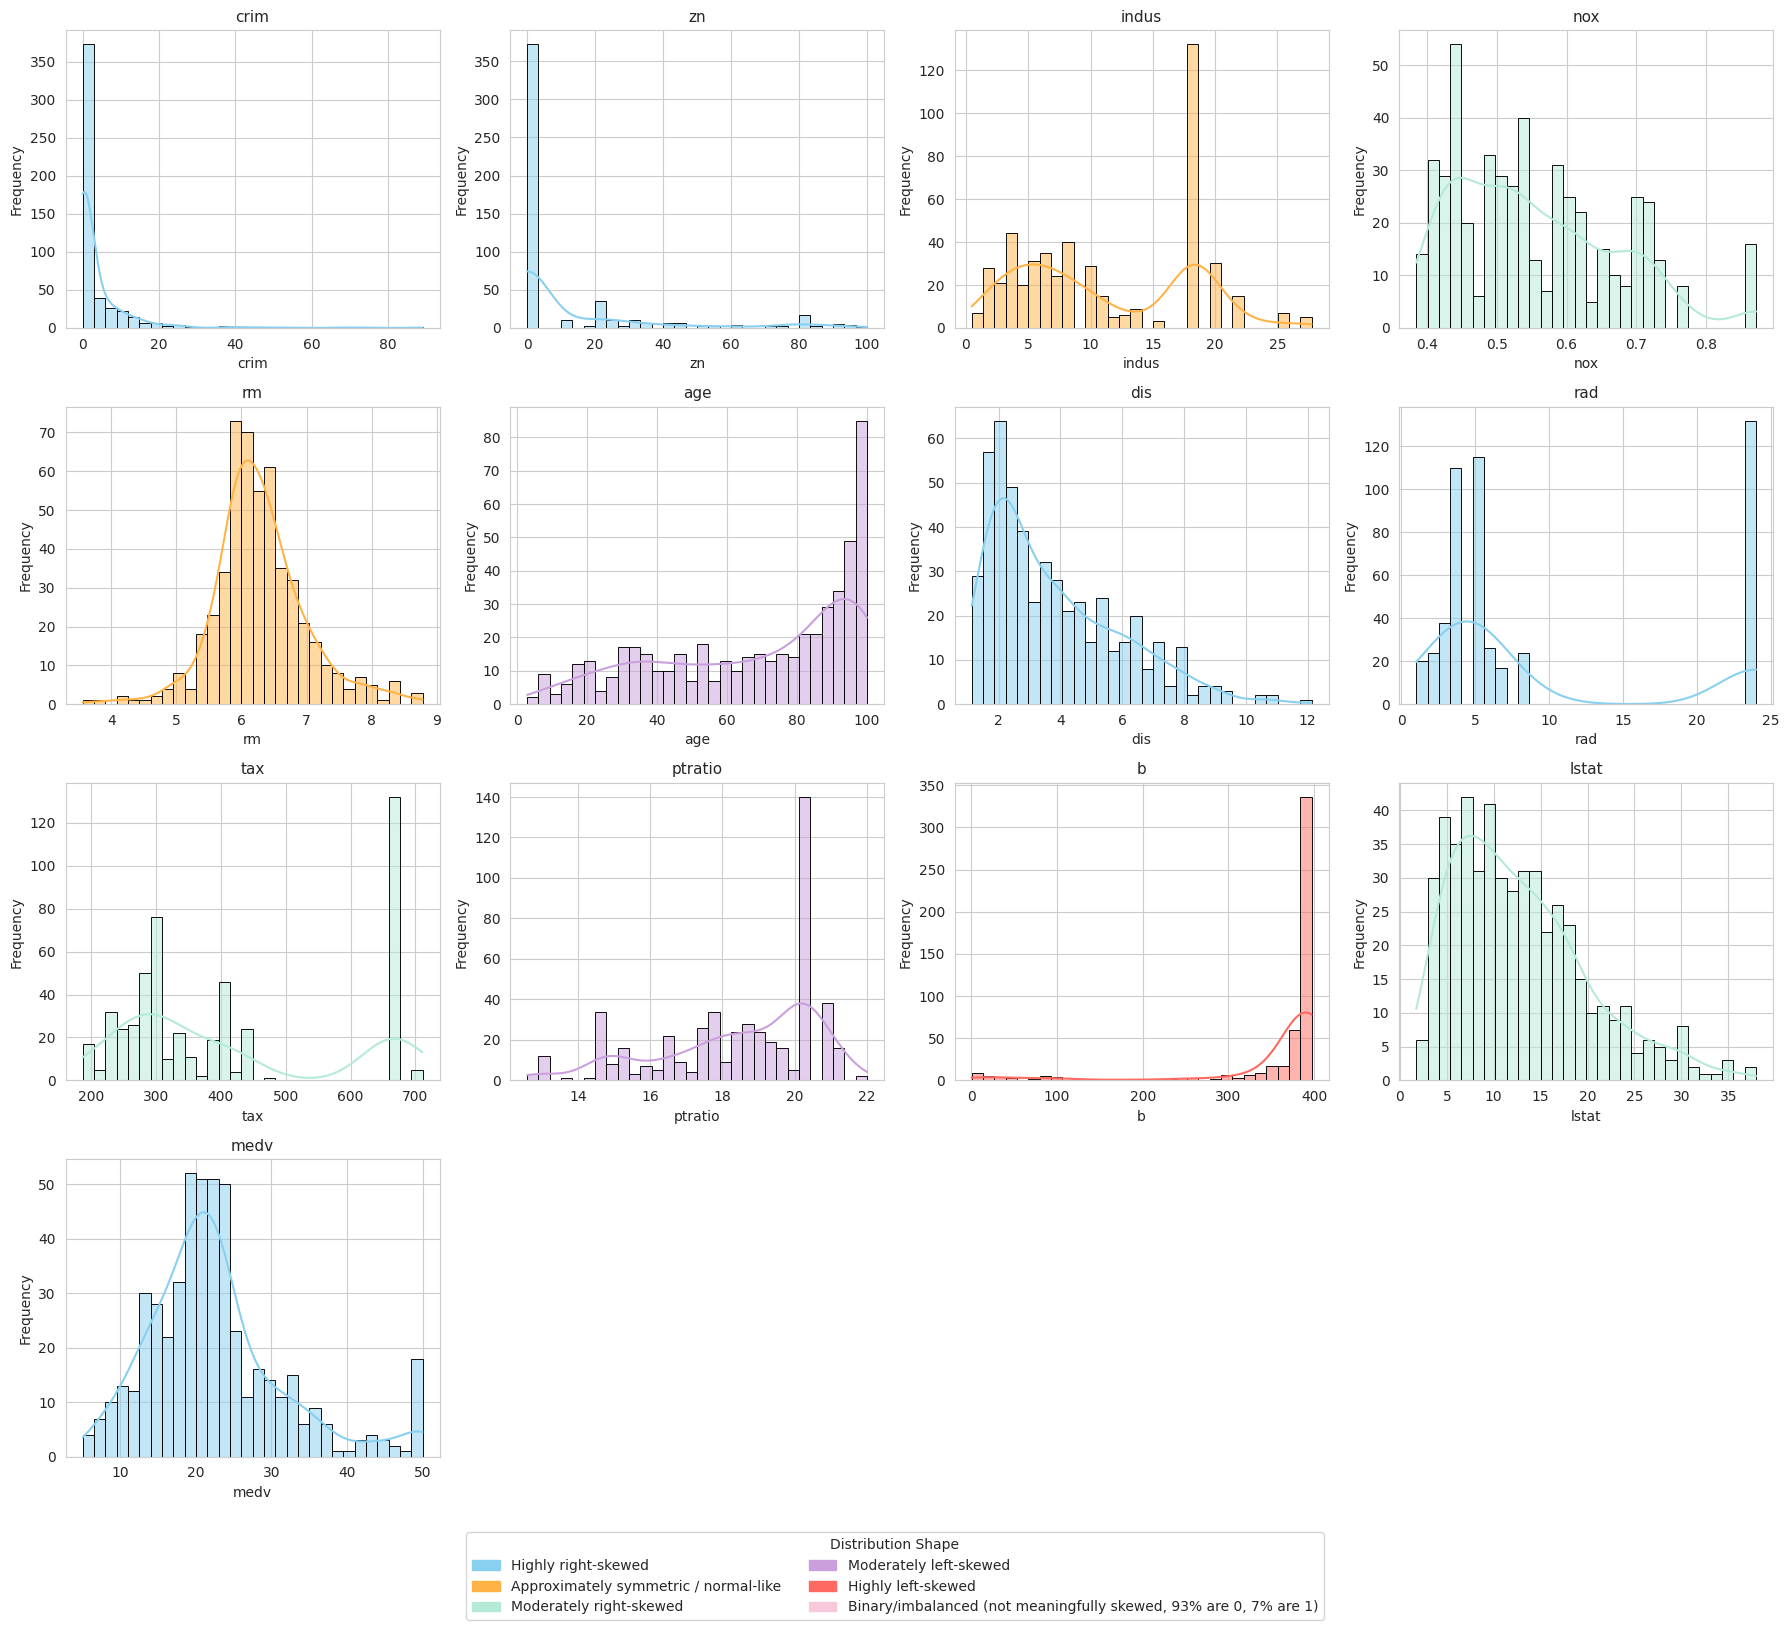

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

shape_color_map = {
    "Highly right-skewed": "#89CFF0",
    "Approximately symmetric / normal-like": "#FFB347",
    "Moderately right-skewed": "#B5EAD7",
    "Moderately left-skewed": "#C9A0DC",
    "Highly left-skewed": "#FF6961",
    "Binary/imbalanced (not meaningfully skewed, 93% are 0, 7% are 1)": "#F8C8DC",
}

sns.set_style("whitegrid")

continuous_cols = [col for col in df.columns if col != 'chas']

fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    shape_label = distribution_summary.loc[distribution_summary['Column'] == col, 'Distribution Shape'].values[0]
    color = shape_color_map.get(shape_label, "#D3D3D3")

    sns.histplot(df[col], bins=30, kde=True, color=color, edgecolor='black', ax=axes[i])
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

for j in range(len(continuous_cols), len(axes)):
    axes[j].axis('off')

# Build a single shared legend for the whole figure, based on the color map
legend_patches = [mpatches.Patch(color=color, label=label) for label, color in shape_color_map.items()]
fig.legend(
    handles=legend_patches,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.02),
    ncol=2,
    fontsize=10,
    title="Distribution Shape",
    frameon=True
)

plt.tight_layout(rect=[0, 0.05, 1, 1])  # leave room at the bottom for the legend
plt.show()

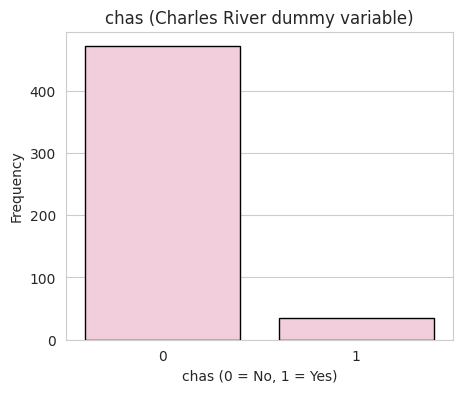

In [10]:
# Define this once, cleanly, instead of repeating the long string as a dictionary key
chas_color = "#F8C8DC"  # pastel pink, same one used in shape_color_map

plt.figure(figsize=(5, 4))
sns.countplot(x=df['chas'], color=chas_color, edgecolor='black')
plt.title("chas (Charles River dummy variable)")
plt.xlabel("chas (0 = No, 1 = Yes)")
plt.ylabel("Frequency")
plt.show()

#Outlier Detection

As we discussed last week, outliers are observations that are unusually far from the rest of the data. Before deciding whether to remove or keep them, we must first detect them.

For each numeric column in the dataset:

Calculate the skewness of the column.

If the distribution is approximately symmetric (e.g., |skewness| < 0.5), use the Z-score method and consider observations with |Z-score| > 3 as potential outliers.

If the distribution is moderately or highly skewed (e.g., |skewness| ≥ 0.5), use the Interquartile Range (IQR) method. Compute Q1, Q3, and IQR, then identify observations outside the interval:

Lower Bound = Q1 - 1.5 * IQR

Upper Bound = Q3 + 1.5 * IQR

Record the indices of the detected outliers for each column and report the number of outliers found.

At this stage, do not remove the outliers. Simply identify them. Their treatment (removal, transformation, capping, or keeping them) should be decided later based on statistical evidence and domain knowledge.

Hint: Use a loop to process every numeric column automatically instead of writing separate code for each variable. This makes your solution reusable for any dataset.

#Remove Outliers from the Dataset

Outliers detected in skewed variables are not removed. Since skewed distributions naturally contain more extreme observations, those outliers should be evaluated more carefully before deciding whether to remove them.

Now that the potential outliers have been identified, create a new cleaned dataset by removing only the observations that were detected as outliers in the approximately normally distributed variables.

Your task is to:

1.	Create a list containing the names of all variables whose absolute skewness is less than 0.5.

2.	Retrieve the outlier indices corresponding to these variables from the dictionary created in the previous step.

3.	Combine all the collected indices into a single list or array. (Hint: a row may appear as an outlier in more than one variable.)

4.	Remove these observations from the original dataset and store the result in a new DataFrame (e.g., df_b). Do not overwrite the original dataset.

5.	Reset the row indices of the new dataset so that they are consecutive.

6.	Display the shape and the first few rows of the cleaned dataset to verify that the operation was successful.



### Outlier Detection

Using the skewness values already computed, each column is routed to the appropriate outlier
detection method: the Z-score method (|Z| > 3) for approximately symmetric distributions
(|skewness| < 0.5), and the IQR method (1.5x beyond Q1/Q3) for moderately or highly skewed
distributions (|skewness| >= 0.5). Outlier indices and counts are recorded per column for later
review. No observations are removed at this stage.

In [11]:
# This command (code) wil help us to create a DataFrame in which we check the skwenss, the method and the number of outliers for each numerical table

from scipy.stats import zscore

outlier_results = {}

for col in df.columns:
    col_skew = skew(df[col])

    if abs(col_skew) < 0.5:
        # Symmetric then Z-score method
        z_scores = zscore(df[col])
        outlier_mask = abs(z_scores) > 3
        method_used = "Z-score"
    else:
        # Skewed then IQR method
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outlier_mask = (df[col] < lower_bound) | (df[col] > upper_bound)
        method_used = "IQR"

    outlier_indices = df.index[outlier_mask].tolist()

    outlier_results[col] = {
        "Skewness": round(col_skew, 2),
        "Method Used": method_used,
        "Number of Outliers": len(outlier_indices),
        "Outlier Indices": outlier_indices
    }

# Build a summary table (indices omitted here for readability; full lists are in outlier_results)
outlier_summary = pd.DataFrame([
    {
        "Column": col,
        "Skewness": info["Skewness"],
        "Method Used": info["Method Used"],
        "Number of Outliers": info["Number of Outliers"]
    }
    for col, info in outlier_results.items()
])

outlier_summary

,Column,Skewness,Method Used,Number of Outliers
0,crim,5.21,IQR,66
1,zn,2.22,IQR,68
2,indus,0.29,Z-score,0
3,chas,3.40,IQR,35
4,nox,0.73,IQR,0
5,rm,0.40,Z-score,8
6,age,-0.60,IQR,0
7,dis,1.01,IQR,5
8,rad,1.00,IQR,0
9,tax,0.67,IQR,0


In [12]:
# Confirm chas outliers are exactly the minority class
chas_outliers = outlier_results['chas']['Outlier Indices']
print("chas values at flagged indices:", df.loc[chas_outliers, 'chas'].unique())

# Confirm which direction b's outliers fall
b_outliers = outlier_results['b']['Outlier Indices']
print("\nb outlier values (first 10):", sorted(df.loc[b_outliers, 'b'])[:10])
print("Overall b range:", df['b'].min(), "to", df['b'].max())

chas values at flagged indices: [1]

b outlier values (first 10): [0.32, 2.52, 2.6, 3.5, 3.65, 6.68, 7.68, 9.32, 10.48, 16.45]
Overall b range: 0.32 to 396.9


### Outlier Detection: Notes on Interpretation

Two columns in the outlier summary require interpretation beyond the raw count before any
treatment decision is made:

- **`chas`** (35 flagged): Verified that every flagged observation corresponds to `chas = 1`, the
  minority class of this binary dummy variable. This is a methodological artifact of applying a
  continuous-distribution outlier method (IQR) to a binary variable, not a genuine outlier
  finding. `chas` should be excluded from outlier treatment entirely.

- **`b`** (77 flagged): Verified that all flagged values fall at the low end of the variable's
  range (0.32 up to the high teens, against an overall range of 0.32–396.9). `b` is a known
  nonlinear transformation of a tract's Black population proportion, `1000(Bk - 0.63)^2`, which
  produces a ceiling value near a specific proportion and falls off sharply elsewhere. The flagged
  points reflect this structural property of the transformation rather than data entry errors or
  anomalous measurements, and should be treated with that context in mind rather than assumed to
  be candidates for removal.

- **`rad`** (0 flagged despite skew = 1.00): IQR found no outliers even though the column is
  skewed. This is consistent with `rad` being a small set of discrete values (largely 1-8, with a
  large repeated cluster at 24) rather than a smoothly continuous variable,  the skew reflects
  this discrete jump, not a fringe of extreme individual observations.

These three cases illustrate why outlier counts should not be acted on mechanically: the same
statistical test can surface a genuine anomaly, a variable-type mismatch, or a structural artifact
of how a variable was engineered, and distinguishing between them requires understanding what each
variable actually represents.

### Removing Outliers from Approximately Symmetric Variables

This step targets only the variables identified as approximately symmetric (|skewness| < 0.5),
since those were the ones flagged using the Z-score method. Outlier rows from these variables are
combined and removed into a new dataset, `df_b`, leaving the original `df` untouched for
comparison and any alternative treatment decisions on the skewed variables later.

In [13]:
# Step 1: Variables with |skewness| < 0.5
symmetric_vars = [col for col, info in outlier_results.items() if abs(info["Skewness"]) < 0.5]
print("Symmetric variables (|skewness| < 0.5):", symmetric_vars)

Symmetric variables (|skewness| < 0.5): ['indus', 'rm']


In [14]:
# Step 2: Retrieve outlier indices for these variables
symmetric_outlier_indices = {col: outlier_results[col]["Outlier Indices"] for col in symmetric_vars}
for col, indices in symmetric_outlier_indices.items():
    print(f"{col}: {len(indices)} outlier indices -> {indices}")

indus: 0 outlier indices -> []
rm: 8 outlier indices -> [225, 257, 262, 364, 365, 367, 374, 406]


In [15]:
# Step 3: Combine all indices into a single list (a row may appear in more than one variable's list)
combined_indices = []
for indices in symmetric_outlier_indices.values():
    combined_indices.extend(indices)

# Remove duplicates, since the same row could be an outlier in both indus and rm
combined_indices = sorted(set(combined_indices))
print(f"Total unique rows to remove: {len(combined_indices)}")
print(combined_indices)

Total unique rows to remove: 8
[225, 257, 262, 364, 365, 367, 374, 406]


In [16]:
# Step 4: Remove these observations from the original dataset into a NEW DataFrame
df_b = df.drop(index=combined_indices).copy()

print(f"Original dataset shape: {df.shape}")
print(f"Cleaned dataset shape (df_b): {df_b.shape}")

Original dataset shape: (506, 14)
Cleaned dataset shape (df_b): (498, 14)


In [17]:
# Step 5: Reset the row indices so they're consecutive
df_b = df_b.reset_index(drop=True)

In [18]:
# Step 6: Verify
print("Shape of df_b:", df_b.shape)
df_b.head()

Shape of df_b: (498, 14)


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


### Summary: Outlier Removal (Symmetric Variables Only)

Variables with |skewness| < 0.5 (`indus`, `rm`) were identified as approximately symmetric and
were the ones evaluated using the Z-score method in the prior step. `indus` had 0 flagged
outliers; `rm` had 8. Combining and de-duplicating these indices yielded 8 unique rows to remove.

These rows were dropped from a copy of the original dataset and stored separately as `df_b`
(shape: 498 rows x 14 columns), with the index reset to remain consecutive. The original `df`
(506 rows) was left unmodified, preserving the option to compare model results with and without
this outlier removal, or to apply a different treatment (e.g., IQR-based capping) to the
remaining skewed variables in a later step.

#Transform skewed variables using a logarithmic transformation

Although outliers have already been addressed, some variables may still have moderately or highly skewed distributions. Highly skewed predictors can weaken the performance of a multiple linear regression model by violating the assumption of a linear relationship between the predictors and the target.

Your task is to create a new version of the dataset in which transformed versions of the skewed variables are added.

1) Create a copy of the cleaned dataset from the previous step. Do not modify the existing dataset directly.

2) Identify all variables whose absolute skewness is greater than or equal to 0.5.

3) Loop through these variables and apply a logarithmic transformation using the np.log1p() function. This function computes log⁡(1+x), making it suitable for variables that may contain zero values (we discussed this last week).

4) For each transformed variable, create a new column with an appropriate name (e.g., by adding a "Log_" prefix) instead of replacing the original variable.

5) Display the shape of the new dataset and inspect the first few rows to verify that the transformed columns have been added successfully.


Note: The objective is to reduce the skewness of the predictors while preserving the original variables. This allows you to compare the original and transformed versions later and decide which representation is more appropriate for the regression model.


### Log Transformation of Skewed Variables

Skewness is recalculated on the cleaned dataset (`df_b`), since removing outliers in the prior
step may have shifted these values. Variables with |skewness| >= 0.5 are then log-transformed
using `np.log1p()`, which computes log(1+x) and safely handles zero values. Transformed columns
are added with a "Log_" prefix, preserving the original variables for later comparison.

In [19]:
import numpy as np

# Step 1: Copy the cleaned dataset — do not modify df_b directly
df_log = df_b.copy()

# Recalculate skewness on df_b (post outlier-removal), not reused from the original df
skew_recalc = {col: skew(df_b[col]) for col in df_b.columns}
print("Recalculated skewness on df_b:")
for col, val in skew_recalc.items():
    print(f"  {col}: {round(val, 2)}")

Recalculated skewness on df_b:
  crim: 5.3
  zn: 2.2
  indus: 0.31
  chas: 3.42
  nox: 0.76
  rm: 0.54
  age: -0.57
  dis: 1.0
  rad: 1.03
  tax: 0.69
  ptratio: -0.78
  b: -2.89
  lstat: 0.86
  medv: 1.08


In [20]:
# Step 2 (revised): Identify variables with |skewness| >= 0.5, excluding chas (categorical, not
# meaningfully addressed by a log transform)
skewed_vars = [col for col, val in skew_recalc.items() if abs(val) >= 0.5 and col != 'chas']
print("Variables to log-transform (|skewness| >= 0.5, excluding chas):", skewed_vars)

Variables to log-transform (|skewness| >= 0.5, excluding chas): ['crim', 'zn', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'b', 'lstat', 'medv']


In [21]:
# Step 3 & 4: Loop through these variables, apply log1p, and add as new "Log_" prefixed columns
for col in skewed_vars:
    df_log[f"Log_{col}"] = np.log1p(df_log[col])

print(f"New columns added: {[f'Log_{col}' for col in skewed_vars]}")

New columns added: ['Log_crim', 'Log_zn', 'Log_nox', 'Log_rm', 'Log_age', 'Log_dis', 'Log_rad', 'Log_tax', 'Log_ptratio', 'Log_b', 'Log_lstat', 'Log_medv']


In [22]:
# Step 5: Verify shape and inspect
print("Shape of df_log:", df_log.shape)
df_log.head()

Shape of df_log: (498, 26)


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,...,Log_nox,Log_rm,Log_age,Log_dis,Log_rad,Log_tax,Log_ptratio,Log_b,Log_lstat,Log_medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,...,0.430483,2.024853,4.192680,1.627278,0.693147,5.693732,2.791165,5.986201,1.788421,3.218876
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,...,0.384582,2.004314,4.380776,1.786261,1.098612,5.493061,2.933857,5.986201,2.316488,3.117950
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,...,0.384582,2.102303,4.128746,1.786261,1.098612,5.493061,2.933857,5.975919,1.615420,3.575151
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,...,0.377066,2.079192,3.845883,1.954757,1.386294,5.407172,2.980619,5.980479,1.371181,3.538057
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,...,0.377066,2.097650,4.010963,1.954757,1.386294,5.407172,2.980619,5.986201,1.845300,3.616309


In [23]:
# Compare skewness before and after transformation for each transformed variable
comparison = pd.DataFrame({
    "Original Skewness": [round(skew(df_log[col]), 2) for col in skewed_vars],
    "Log-Transformed Skewness": [round(skew(df_log[f"Log_{col}"]), 2) for col in skewed_vars]
}, index=skewed_vars)

comparison

,Original Skewness,Log-Transformed Skewness
crim,5.30,1.30
zn,2.20,1.19
nox,0.76,0.61
rm,0.54,0.18
age,-0.57,-1.57
dis,1.00,0.32
rad,1.03,0.55
tax,0.69,0.34
ptratio,-0.78,-0.98
b,-2.89,-4.43


### Before/After Visualization: Original vs. Log-Transformed Distributions

For each variable identified as skewed, the original and log-transformed distributions are
plotted side by side. The log-transformed histogram is colored green if the transformation
successfully brought |skewness| below 0.5, or red if the variable remains skewed even after
transformation, making it immediately visible which variables benefited from the log transform.

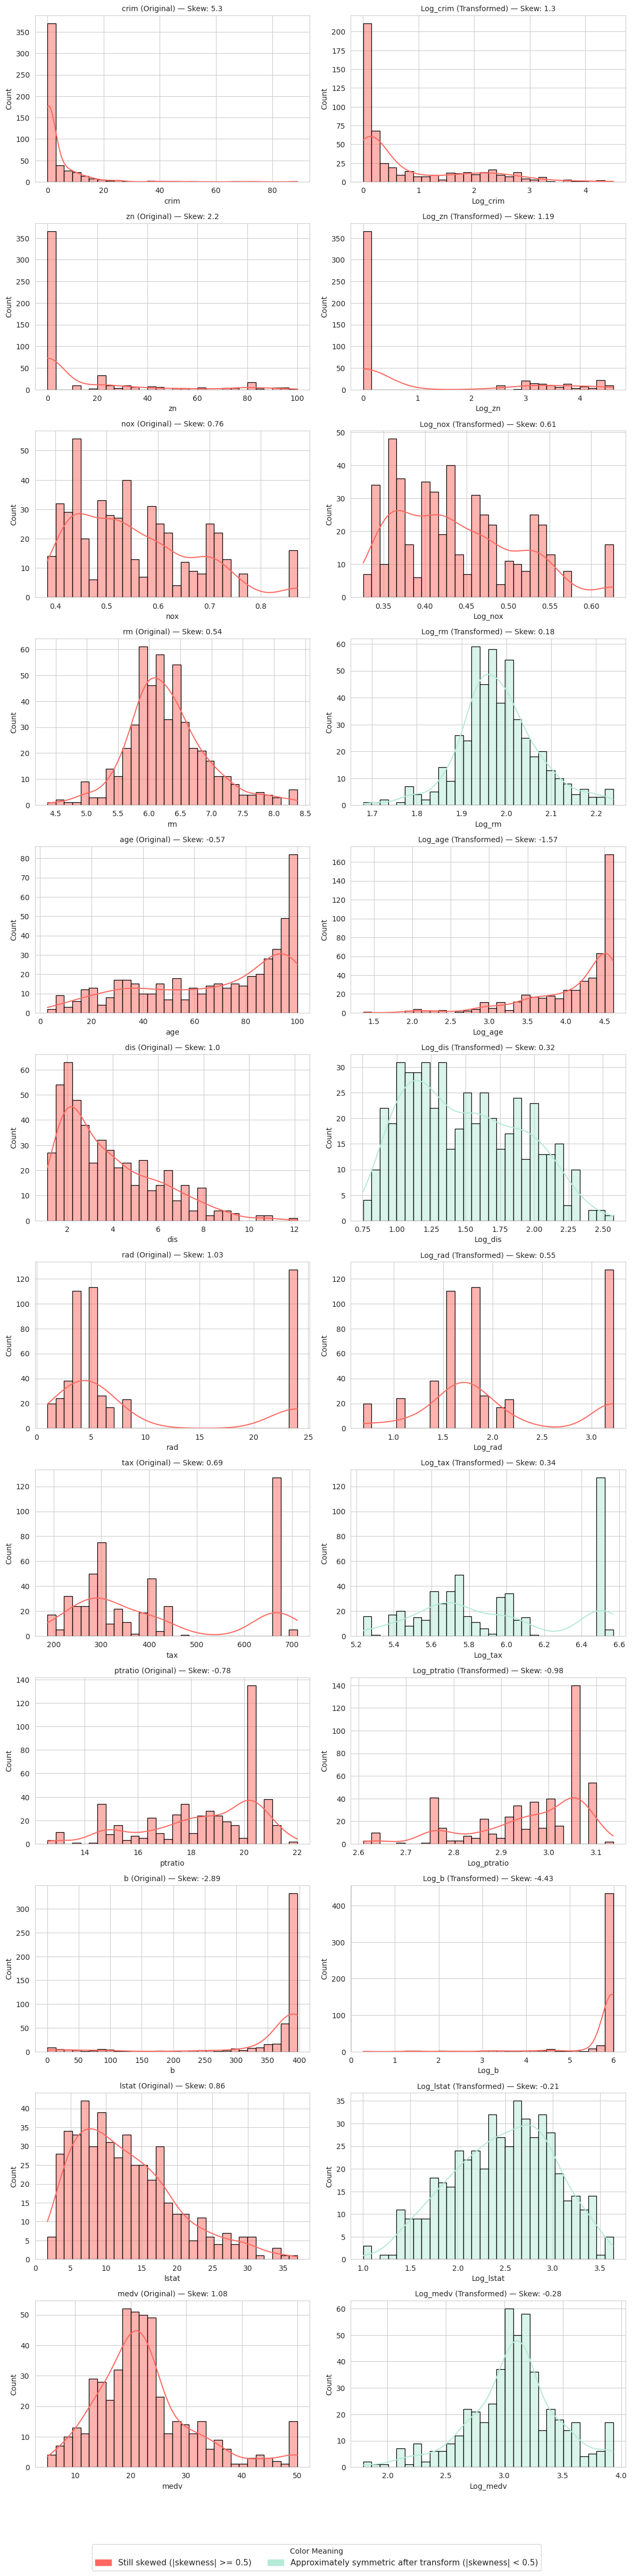

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

pastel_red = "#FF6961"
pastel_green = "#B5EAD7"

sns.set_style("whitegrid")

n_vars = len(skewed_vars)
fig, axes = plt.subplots(nrows=n_vars, ncols=2, figsize=(12, 4 * n_vars))

for i, col in enumerate(skewed_vars):
    original_skew = skew(df_log[col])
    log_skew = skew(df_log[f"Log_{col}"])

    # Original: always red, since these are all pre-flagged as skewed by definition
    sns.histplot(df_log[col], bins=30, kde=True, color=pastel_red, edgecolor='black', ax=axes[i, 0])
    axes[i, 0].set_title(f"{col} (Original) — Skew: {round(original_skew, 2)}", fontsize=10)
    axes[i, 0].set_xlabel(col)

    # Log-transformed: green if fixed (|skew| < 0.5), red if still skewed
    log_color = pastel_green if abs(log_skew) < 0.5 else pastel_red
    sns.histplot(df_log[f"Log_{col}"], bins=30, kde=True, color=log_color, edgecolor='black', ax=axes[i, 1])
    axes[i, 1].set_title(f"Log_{col} (Transformed) — Skew: {round(log_skew, 2)}", fontsize=10)
    axes[i, 1].set_xlabel(f"Log_{col}")

# Shared legend explaining the color meaning
legend_patches = [
    mpatches.Patch(color=pastel_red, label="Still skewed (|skewness| >= 0.5)"),
    mpatches.Patch(color=pastel_green, label="Approximately symmetric after transform (|skewness| < 0.5)")
]
fig.legend(
    handles=legend_patches,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.01),
    ncol=2,
    fontsize=11,
    title="Color Meaning",
    frameon=True
)

plt.tight_layout(rect=[0, 0.02, 1, 1])
plt.show()

### Effectiveness of the Log Transformation

Applying `np.log1p()` improved skewness for most originally right-skewed variables. `rm`, `dis`,
`tax`, `lstat`, and `medv` were successfully brought to approximately symmetric distributions
(|skewness| < 0.5) after transformation. `crim`, `zn`, and `nox` improved meaningfully but
remained moderately-to-highly skewed even after transformation, for `zn` in particular, this is
consistent with its large mass of zero values (372 of 506 original rows), which a log transform
cannot meaningfully redistribute.

Critically, every variable that was originally left-skewed became more skewed after the log
transform: `age` (-0.57 to -1.57), `ptratio` (-0.78 to -0.98), and especially `b` (-2.89 to -4.43).
This is expected mathematical behavior rather than an error: `log1p()` compresses large values and
stretches small ones, which corrects right-skewed distributions but actively exacerbates
left-skewed ones. Log transformation should therefore only be applied to right-skewed predictors;
for `age`, `ptratio`, and `b`, the original (untransformed) variable should be preferred over its
"Log_" version, or an alternative transformation (e.g., a reflection/power transform for left-skew)
should be considered in future work.

#Replace the original skewed variables

After creating the logarithmically transformed variables, the dataset now contains both the original skewed variables and their transformed versions. Since both versions represent the same information, keeping both will introduce redundancy and increase the risk of multicollinearity in the regression model.

Your task is to create a new version of the dataset that retains only the transformed variables.

1) Create a copy of the dataset from the previous step.

2) Remove the original skewed variables that were transformed, while keeping their corresponding log-transformed variables.

3) Store the result in a new DataFrame (e.g., df_d) to preserve the previous version of the data.

4) Display the shape and the first few rows of the new dataset to verify that the original skewed columns have been removed successfully.

Note: The goal is to replace the original skewed predictors with their log-transformed counterparts. This simplifies the dataset, reduces redundancy, and prepares the data for feature selection and Multiple Linear Regression.

### Replacing Original Skewed Variables with Log-Transformed Versions

The dataset is simplified by removing the original skewed variables that were transformed,
retaining only their "Log_" counterparts. This avoids redundancy and reduces multicollinearity
risk. Note: as shown in the prior comparison, the log transform did not improve, and in fact
worsened, skewness for `age`, `ptratio`, and `b`. These are retained as their log versions here
per the assignment's instruction, but are flagged for reconsideration in the feature selection
step that follows, since their original (untransformed) form may be statistically preferable.

In [25]:
# Step 1: Copy the dataset from the previous step
df_d = df_log.copy()

# Step 2: Remove the original skewed variables that were transformed,
# keeping only their Log_ counterparts
df_d = df_d.drop(columns=skewed_vars)

# Step 3: (df_d is already the new DataFrame, preserving df_log untouched)

# Step 4: Verify
print("Shape of df_d:", df_d.shape)
df_d.head()

Shape of df_d: (498, 14)


,indus,chas,Log_crim,Log_zn,Log_nox,Log_rm,Log_age,Log_dis,Log_rad,Log_tax,Log_ptratio,Log_b,Log_lstat,Log_medv
0,2.31,0,0.006300,2.944439,0.430483,2.024853,4.192680,1.627278,0.693147,5.693732,2.791165,5.986201,1.788421,3.218876
1,7.07,0,0.026944,0.000000,0.384582,2.004314,4.380776,1.786261,1.098612,5.493061,2.933857,5.986201,2.316488,3.117950
2,7.07,0,0.026924,0.000000,0.384582,2.102303,4.128746,1.786261,1.098612,5.493061,2.933857,5.975919,1.615420,3.575151
3,2.18,0,0.031857,0.000000,0.377066,2.079192,3.845883,1.954757,1.386294,5.407172,2.980619,5.980479,1.371181,3.538057
4,2.18,0,0.066770,0.000000,0.377066,2.097650,4.010963,1.954757,1.386294,5.407172,2.980619,5.986201,1.845300,3.616309


#Perform correlation analysis and visualize the correlation matrix

Before building a Multiple Linear Regression model, it is important to understand how the variables are related to one another. Correlation analysis helps identify variables that are strongly or weakly related and provides valuable insights for feature selection.

Your task is to:

1) Compute the correlation matrix for all numeric variables in the dataset.

2) Display the correlation matrix to inspect the correlation coefficients between every pair of variables.

3) Create a heatmap to visualize the correlation matrix. Use an appropriate color scale so that strong positive, strong negative, and weak correlations can be easily distinguished.

4) Display the numerical correlation coefficients on the heatmap to make interpretation easier.

5) Add a meaningful title and adjust the figure size so that all variables and correlation values are clearly visible.

Note: The heatmap is an exploratory analysis tool. In the following steps, you will use it to identify:

predictors that have little correlation with the target and may be removed, and predictors that are highly correlated with one another, which may indicate multicollinearity and require further feature selection.

### Correlation Analysis

The correlation matrix is computed across all numeric variables in the log-transformed, redundancy-reduced
dataset (`df_d`). A scatter-style heatmap visualizes the strength and direction of each pairwise
correlation, using point size for the magnitude of the correlation and color for its sign/strength;
numeric coefficients are annotated directly on the plot for precise interpretation.

In [26]:
# Step 1 & 2: Compute and display the correlation matrix
numeric_cols = df_d.select_dtypes(include=['int64', 'float64']).columns.tolist()

corr = df_d[numeric_cols].corr()
corr

,indus,chas,Log_crim,Log_zn,Log_nox,Log_rm,Log_age,Log_dis,Log_rad,Log_tax,Log_ptratio,Log_b,Log_lstat,Log_medv
indus,1.000000,0.057474,0.657223,-0.590484,0.775499,-0.397027,0.545432,-0.759957,0.566292,0.701164,0.357149,-0.284250,0.607209,-0.540234
chas,0.057474,1.000000,-0.018629,-0.038017,0.082045,0.066301,0.091835,-0.088499,0.000935,-0.047025,-0.128050,0.053694,-0.063675,0.166467
Log_crim,0.657223,-0.018629,1.000000,-0.408382,0.714914,-0.281167,0.472401,-0.654728,0.859603,0.822835,0.368448,-0.448109,0.560212,-0.600998
Log_zn,-0.590484,-0.038017,-0.408382,1.000000,-0.571207,0.346168,-0.526472,0.657613,-0.348936,-0.377729,-0.446915,0.168025,-0.486944,0.399311
Log_nox,0.775499,0.082045,0.714914,-0.571207,1.000000,-0.336183,0.658984,-0.836391,0.609915,0.666136,0.184808,-0.300892,0.604279,-0.528846
Log_rm,-0.397027,0.066301,-0.281167,0.346168,-0.336183,1.000000,-0.233905,0.265640,-0.192502,-0.288948,-0.328865,0.078131,-0.682827,0.651850
Log_age,0.545432,0.091835,0.472401,-0.526472,0.658984,-0.233905,1.000000,-0.695375,0.389166,0.413399,0.216078,-0.187030,0.568975,-0.405675
Log_dis,-0.759957,-0.088499,-0.654728,0.657613,-0.836391,0.265640,-0.695375,1.000000,-0.532606,-0.582632,-0.224490,0.257906,-0.536353,0.406354
Log_rad,0.566292,0.000935,0.859603,-0.348936,0.609915,-0.192502,0.389166,-0.532606,1.000000,0.836450,0.413360,-0.383304,0.457690,-0.452209
Log_tax,0.701164,-0.047025,0.822835,-0.377729,0.666136,-0.288948,0.413399,-0.582632,0.836450,1.000000,0.404362,-0.370970,0.523458,-0.558116


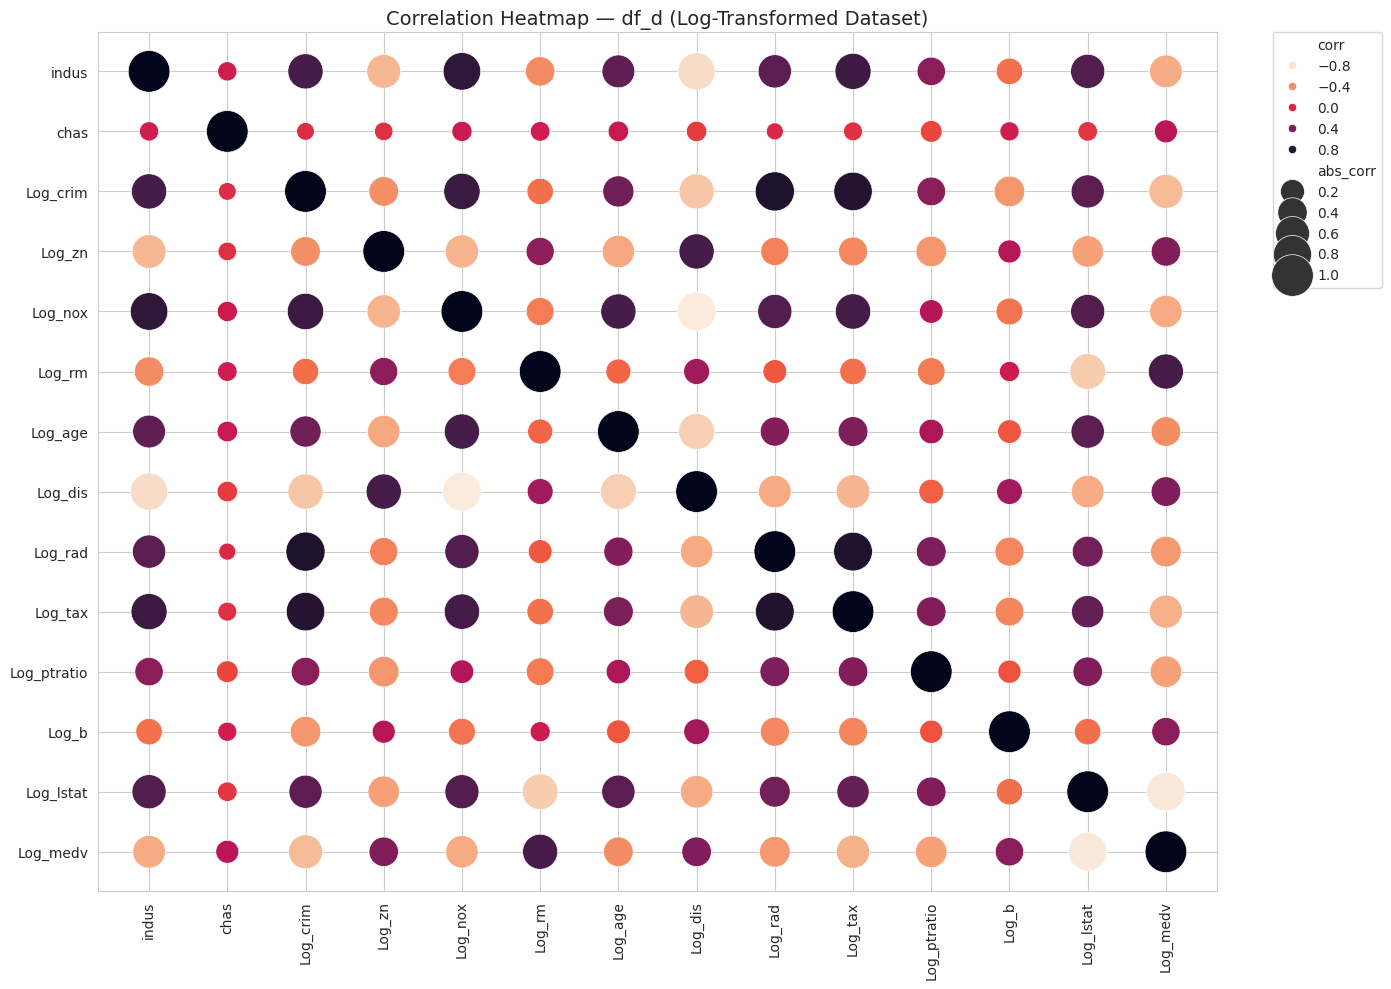

In [27]:
# Melt for scatter-style heatmap
corr_melt = corr.reset_index().melt(id_vars='index')
corr_melt.columns = ['var1', 'var2', 'corr']
corr_melt['abs_corr'] = corr_melt['corr'].abs()

# Colormap
cmap = sns.color_palette("rocket_r", as_cmap=True)

plt.figure(figsize=(14, 10))

# Create the scatter heatmap with larger dot sizes
ax = sns.scatterplot(
    data=corr_melt,
    x="var1",
    y="var2",
    hue="corr",
    size="abs_corr",
    sizes=(150, 900),
    palette=cmap,
    edgecolor="white",
    linewidth=0.5,
    legend="brief"
)

plt.xticks(rotation=90)
plt.xlabel("")
plt.ylabel("")
plt.title("Correlation Heatmap — df_d (Log-Transformed Dataset)", fontsize=14)

# Move legend OUTSIDE the plot
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0
)

plt.tight_layout()
plt.show()

#Identify predictors weakly correlated with the target


Not all predictors contribute meaningfully to predicting the target variable. Variables that have a very weak linear relationship with the target often provide little predictive value and may unnecessarily increase the complexity of the model.

Your task is to:

1) Create a copy of the dataset from the previous step to preserve the original version.

2) Write a reusable function that accepts a DataFrame, the name of the target variable, and a correlation threshold as inputs.

3) Within the function, compute the correlation matrix for the dataset.

4) Extract the correlation coefficient between each predictor and the target variable, excluding the target's correlation with itself.

5) Identify all predictors whose absolute correlation with the target is less than 0.30. Use the absolute value because both positive and negative correlations may indicate useful relationships.

6) Display the names of these predictors along with their correlation coefficients in a clear and readable format, and report how many predictors satisfy the condition.

7) Return the names of the weakly correlated predictors as a Python list. This list will be used in the next step to remove these variables from the dataset.

Note: The threshold of |correlation| < 0.30 is a commonly used rule of thumb for identifying predictors that have a weak linear relationship with the target. Removing such predictors can simplify the model, reduce noise, and improve interpretability without significantly affecting predictive performance.

### Identifying Predictors Weakly Correlated with the Target

A reusable function computes the correlation of every predictor against the target variable and
flags those with |correlation| < 0.30, a common rule-of-thumb threshold for a weak linear
relationship. These predictors contribute little explanatory value to a linear model and are
candidates for removal in the next step.

In [28]:
# Step 1: Copy the dataset from the previous step
df_e = df_d.copy()

In [29]:
def identify_weak_predictors(dataframe, target, threshold=0.30):
    """
    Identifies predictors weakly correlated with the target variable.

    Parameters:
        dataframe (pd.DataFrame): The dataset containing numeric predictors and the target.
        target (str): The name of the target column.
        threshold (float): The absolute correlation threshold below which a predictor is
                            considered weakly correlated (default 0.30).

    Returns:
        list: Names of predictors whose |correlation| with the target is below the threshold.
    """
    # Step 3: Compute the correlation matrix
    corr_matrix = dataframe.corr()

    # Step 4: Extract correlation with the target, excluding the target itself
    target_corr = corr_matrix[target].drop(index=target)

    # Step 5: Identify predictors with |correlation| < threshold
    weak_mask = target_corr.abs() < threshold
    weak_predictors = target_corr[weak_mask]

    # Step 6: Display results
    print(f"Predictors with |correlation| < {threshold} against '{target}':\n")
    for predictor, value in weak_predictors.sort_values(key=abs).items():
        print(f"  {predictor}: {round(value, 3)}")
    print(f"\nTotal weakly correlated predictors found: {len(weak_predictors)}")

    # Step 7: Return the names as a list
    return weak_predictors.index.tolist()

In [30]:
# Run the function on df_e, targeting Log_medv (since medv was replaced by its log version in df_d)
weak_predictors = identify_weak_predictors(df_e, target='Log_medv', threshold=0.30)

Predictors with |correlation| < 0.3 against 'Log_medv':

  chas: 0.166

Total weakly correlated predictors found: 1


### Result: Weak Predictor Identified

Only one predictor fell below the |correlation| < 0.30 threshold against `Log_medv`: **`chas`**,
with a correlation coefficient of 0.166. This is consistent with `chas` being a binary indicator
(bordering the Charles River or not) that has historically shown only a weak linear relationship
with housing value in this dataset, a modest effect on price, but not strong enough to be a
useful linear predictor on its own.

This finding is also consistent with `chas`'s behavior throughout the analysis so far: it was the
only variable excluded from the log-transformation step (being categorical, not skewed in the
meaningful sense), and its earlier "outlier" flags were shown to be an artifact of applying a
continuous-distribution method to a binary variable rather than genuine anomalies. The weak
correlation result reinforces that `chas` contributes limited value to a linear model of `medv`,
and it is the sole candidate for removal in the next step.

#Identify predictors that are highly correlated with one another

After removing predictors that are weakly related to the target, the next step is to identify multicollinearity among the remaining predictors. Multicollinearity occurs when two or more predictors contain very similar information, which can make the regression coefficients unstable and difficult to interpret.

Your task is to:

1) Create a new version of the dataset by removing the predictors identified in the previous step as being weakly correlated with the target.

2) Write a reusable function that accepts a DataFrame, the name of the target variable, and a correlation threshold as inputs.

3) Compute the correlation matrix for the dataset.

4) Exclude the target variable from the analysis so that only the relationships among the predictors are considered.

5) Identify all pairs of predictors whose absolute correlation coefficient is greater than 0.70.

6) Ensure that each predictor pair appears only once in the output (e.g., report A-B but not B-A).

7) Display the highly correlated predictor pairs together with their absolute correlation coefficients, sorted from the strongest to the weakest correlation.

Note: A correlation coefficient greater than 0.70 is a commonly used rule of thumb for identifying potential multicollinearity. At this stage, do not remove any variables yet. Simply identify the highly correlated predictor pairs. In the next step, you will decide which predictor from each pair should be retained based on its relationship with the target variable, domain knowledge, and overall model quality.

### Revision: Retaining `chas` for the Multicollinearity Check

`chas` is a categorical (binary) variable, not continuous. While it was flagged as weakly
correlated with the target in the prior step using Pearson/point-biserial correlation (a valid
but limited test for a binary variable), the multicollinearity check itself is concerned with
redundancy among continuous predictors. `chas` is therefore restored to the working dataset and
excluded only from the predictor-pair correlation analysis, rather than removed from the dataset
altogether at this stage.

In [31]:
# Step 1 (revised): Remove only the CONTINUOUS weak predictors, restoring chas
# since categorical variables shouldn't be evaluated/removed via linear correlation this way
weak_predictors_continuous = [col for col in weak_predictors if col != 'chas']
df_f = df_e.drop(columns=weak_predictors_continuous).copy()

print(f"Shape after removing weak CONTINUOUS predictors only: {df_f.shape}")
print(f"Columns remaining: {df_f.columns.tolist()}")

Shape after removing weak CONTINUOUS predictors only: (498, 14)
Columns remaining: ['indus', 'chas', 'Log_crim', 'Log_zn', 'Log_nox', 'Log_rm', 'Log_age', 'Log_dis', 'Log_rad', 'Log_tax', 'Log_ptratio', 'Log_b', 'Log_lstat', 'Log_medv']


In [32]:
def identify_multicollinear_pairs(dataframe, target, threshold=0.70, exclude_cols=None):
    """
    Identifies pairs of predictors that are highly correlated with one another (multicollinearity),
    excluding the target variable and any specified categorical columns from the pairwise comparison.

    Parameters:
        dataframe (pd.DataFrame): The dataset containing numeric predictors and the target.
        target (str): The name of the target column, to be excluded from predictor-pair analysis.
        threshold (float): The absolute correlation threshold above which a pair is flagged
                            (default 0.70).
        exclude_cols (list): Additional columns to exclude from the pairwise check (e.g.,
                              categorical variables like 'chas') since multicollinearity is a
                              concept specific to relationships among continuous predictors.

    Returns:
        pd.DataFrame: Highly correlated predictor pairs with their absolute correlation
                      coefficients, sorted from strongest to weakest.
    """
    if exclude_cols is None:
        exclude_cols = []

    corr_matrix = dataframe.corr()

    # Exclude the target AND any categorical columns from the predictor-pair analysis
    cols_to_drop = [target] + exclude_cols
    predictors_only = corr_matrix.drop(index=cols_to_drop, columns=cols_to_drop)

    pairs = []
    cols = predictors_only.columns
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            var1 = cols[i]
            var2 = cols[j]
            corr_value = predictors_only.loc[var1, var2]
            if abs(corr_value) > threshold:
                pairs.append({
                    "Predictor 1": var1,
                    "Predictor 2": var2,
                    "Correlation": round(corr_value, 3),
                    "Abs Correlation": round(abs(corr_value), 3)
                })

    result_df = pd.DataFrame(pairs).sort_values(by="Abs Correlation", ascending=False).reset_index(drop=True)

    print(f"Highly correlated CONTINUOUS predictor pairs (|correlation| > {threshold}):\n")
    print(result_df)
    print(f"\nTotal pairs found: {len(result_df)}")

    return result_df

In [33]:
# Run the function on df_f, targeting Log_medv, explicitly excluding chas (categorical)
multicollinear_pairs = identify_multicollinear_pairs(df_f, target='Log_medv', threshold=0.70, exclude_cols=['chas'])

Highly correlated CONTINUOUS predictor pairs (|correlation| > 0.7):

  Predictor 1 Predictor 2  Correlation  Abs Correlation
0    Log_crim     Log_rad        0.860            0.860
1     Log_nox     Log_dis       -0.836            0.836
2     Log_rad     Log_tax        0.836            0.836
3    Log_crim     Log_tax        0.823            0.823
4       indus     Log_nox        0.775            0.775
5       indus     Log_dis       -0.760            0.760
6    Log_crim     Log_nox        0.715            0.715
7       indus     Log_tax        0.701            0.701

Total pairs found: 8


#Visualize strong correlations among predictors

Although the previous step identified highly correlated predictor pairs in a table, a heatmap provides a more intuitive way to visualize these relationships. By displaying only the strongest correlations, the heatmap makes it easier to identify groups of predictors that may cause multicollinearity.

Your task is to:

1) Create a list containing only the predictor variables, excluding the target variable.

2) Compute the correlation matrix for these predictors.

3) Create a mask that retains only predictor pairs whose absolute correlation coefficient is greater than 0.70.

4) Apply the mask to the correlation matrix so that weaker correlations are hidden from the visualization.

5) Plot the resulting matrix as a heatmap, displaying the correlation coefficients on the figure.

6) Add an appropriate title and adjust the figure size so that the heatmap is easy to read.

Note: The purpose of this visualization is to highlight only the predictor pairs that may introduce multicollinearity. The heatmap should make it easier to determine which variables require further investigation before building the Multiple Linear Regression model.


### Visualizing Strong Correlations Among Predictors

A masked heatmap isolates only the predictor pairs exceeding |correlation| > 0.70, making the two
correlated clusters identified earlier (crime/highway-access/tax, and industrial/pollution/
distance) visually apparent. Scatter plots for each flagged pair provide a direct visual
confirmation of the linear relationship underlying each correlation coefficient.

Variables involved in high-correlation pairs: ['Log_crim', 'Log_dis', 'Log_nox', 'Log_rad', 'Log_tax', 'indus']

Cells flagged by mask (should be 2x the 8 pairs found earlier): 16
Assumption check passed: mask matches the 8 pairs identified in the previous step.


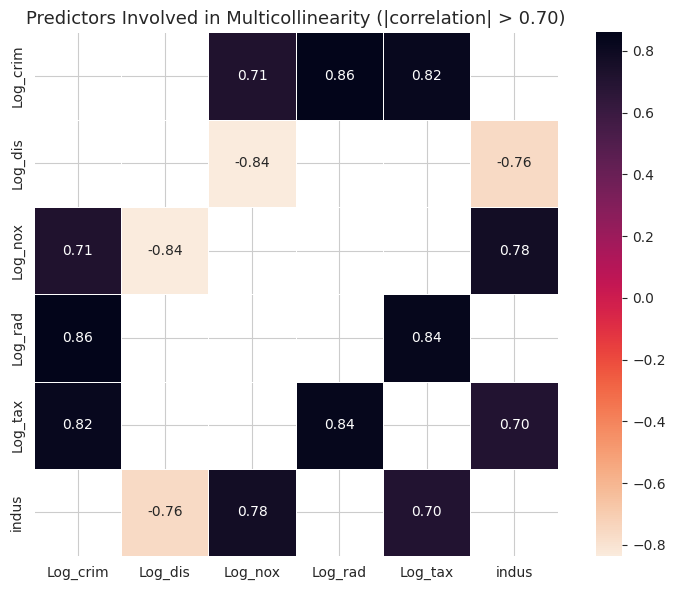

In [37]:
# Step 1: Extract only the variables that actually appear in the flagged high-correlation pairs
# (built directly from multicollinear_pairs, not hardcoded, so it stays correct if the pairs change)
involved_vars = sorted(set(multicollinear_pairs['Predictor 1']).union(set(multicollinear_pairs['Predictor 2'])))
print("Variables involved in high-correlation pairs:", involved_vars)

# Step 2: Correlation matrix restricted to ONLY these variables
subset_corr = df_f[involved_vars].corr()

# Step 3: Mask that keeps only |correlation| > 0.70, excluding the diagonal (always 1.0)
mask_keep = (subset_corr.abs() > 0.70) & (subset_corr.abs() < 1.0)

# Step 4: Apply the mask
masked_subset_corr = subset_corr.where(mask_keep)

# Assumption check: confirm the mask is behaving as expected before plotting
# (every off-diagonal cell we keep should match a pair already found in multicollinear_pairs)
n_flagged_cells = mask_keep.sum().sum()  # counts each pair twice (symmetric matrix)
print(f"\nCells flagged by mask (should be 2x the {len(multicollinear_pairs)} pairs found earlier): {n_flagged_cells}")
assert n_flagged_cells == len(multicollinear_pairs) * 2, "Mismatch — mask isn't isolating the same pairs as before!"
print("Assumption check passed: mask matches the 8 pairs identified in the previous step.")

# Step 5 & 6: Plot the masked heatmap, restricted to only these 6 variables
plt.figure(figsize=(8, 6))
sns.heatmap(
    masked_subset_corr,
    annot=True,
    fmt=".2f",
    cmap="rocket_r",
    cbar=True,
    linewidths=0.5,
    linecolor='white',
    square=True
)
plt.title("Predictors Involved in Multicollinearity (|correlation| > 0.70)", fontsize=13)
plt.tight_layout()
plt.show()

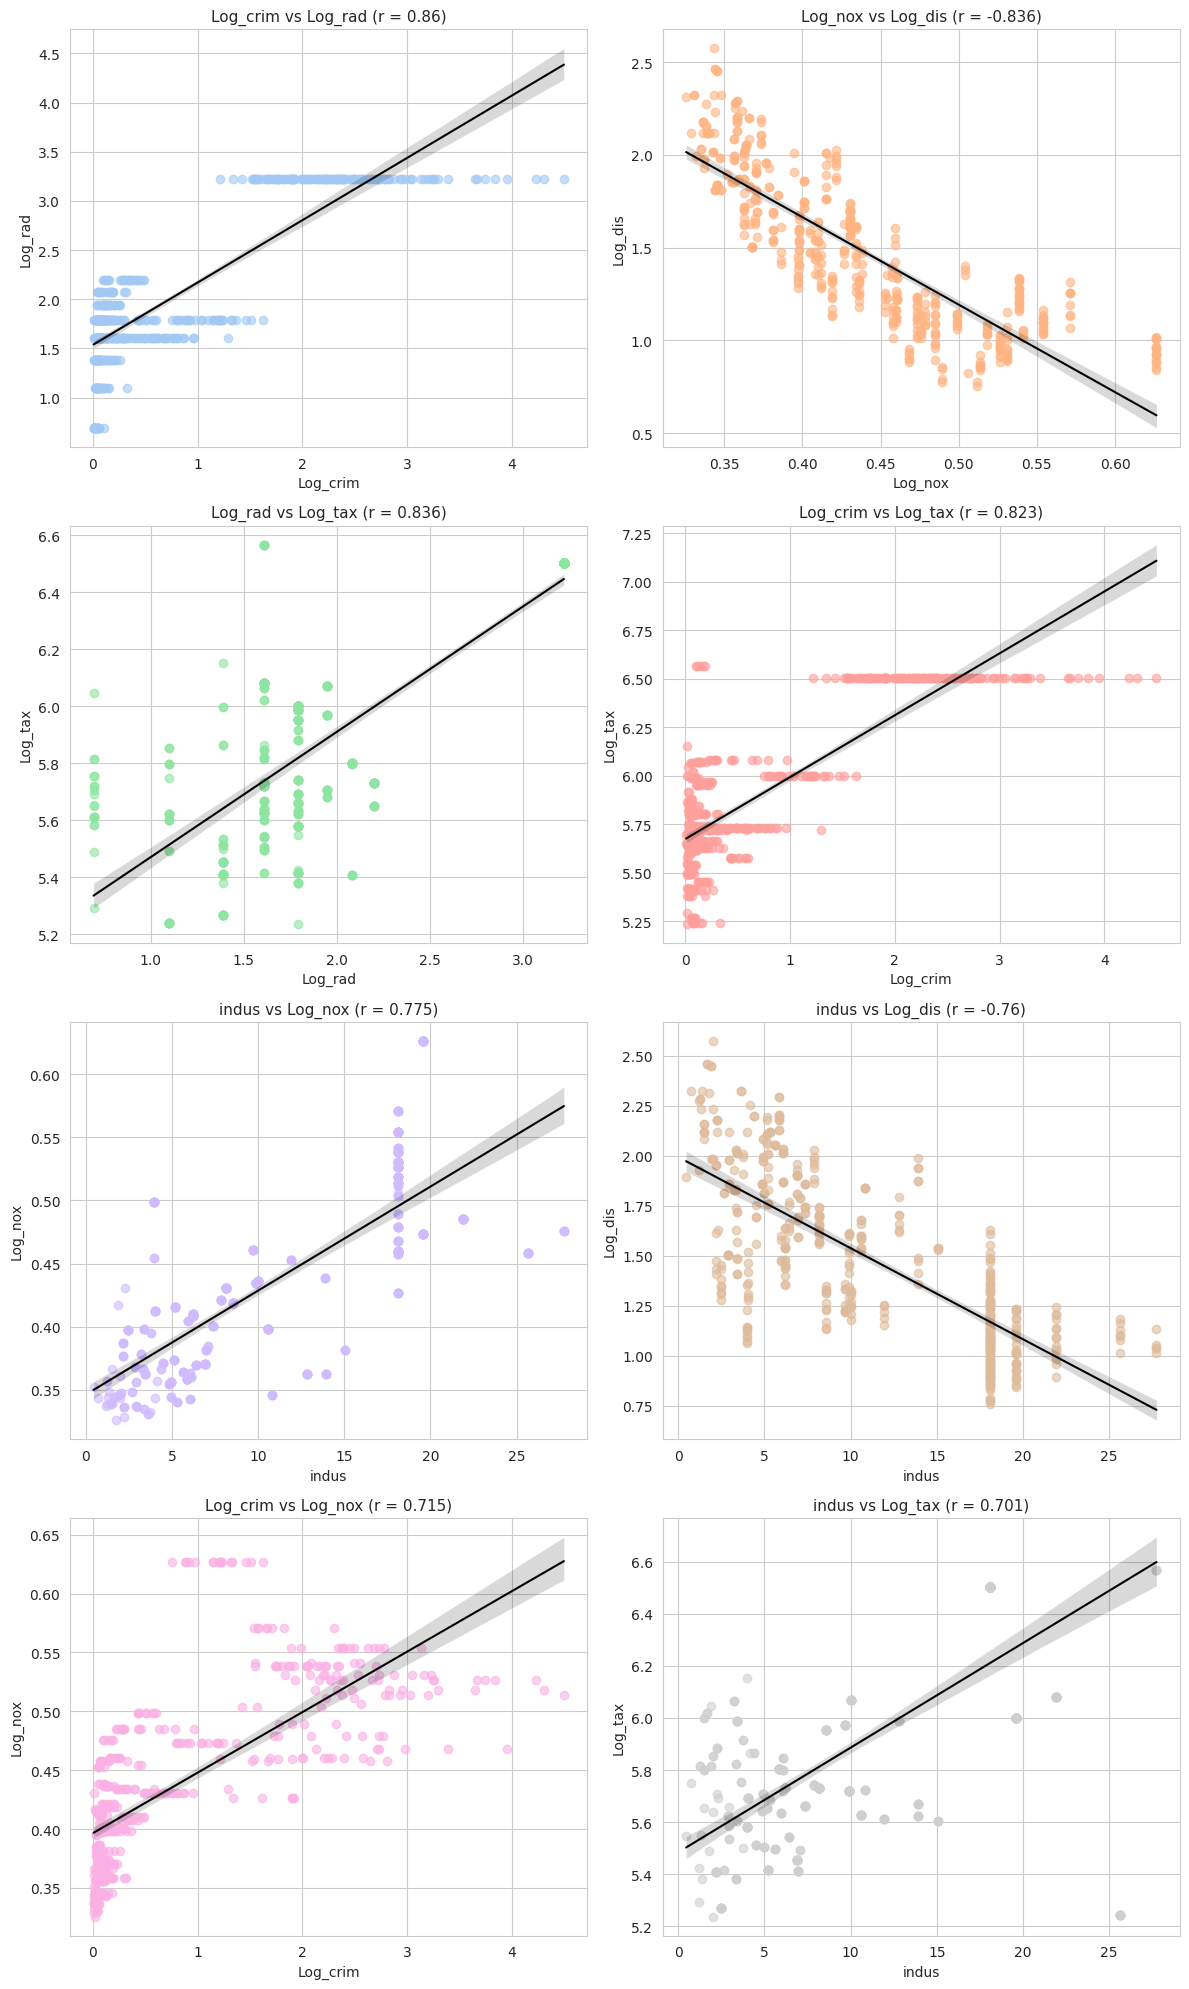

In [38]:
pairs_to_plot = list(zip(multicollinear_pairs['Predictor 1'], multicollinear_pairs['Predictor 2']))

n_pairs = len(pairs_to_plot)
n_cols = 2
n_rows = int(np.ceil(n_pairs / n_cols))

# Generate a distinct pastel color for each pair
pastel_colors = sns.color_palette("pastel", n_colors=n_pairs)

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(12, 5 * n_rows))
axes = axes.flatten()

# Calculate the correlation matrix for df_f, which contains the relevant predictors
predictor_corr = df_f.corr()

for i, (var1, var2) in enumerate(pairs_to_plot):
    corr_val = predictor_corr.loc[var1, var2]
    sns.regplot(
        data=df_f, x=var1, y=var2,
        ax=axes[i],
        scatter_kws={"alpha": 0.6, "color": pastel_colors[i]},
        line_kws={"color": "black", "linewidth": 1.5}
    )
    axes[i].set_title(f"{var1} vs {var2} (r = {round(corr_val, 3)})", fontsize=11)

# Hide any unused subplot axes
for j in range(len(pairs_to_plot), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

#Remove collinear predictors and verify the results

After identifying the highly correlated predictor pairs, the next step is to reduce multicollinearity by removing one predictor from each highly correlated pair. The goal is to retain the most informative predictors while eliminating redundant ones.

Your task is to:

1) Review the table and heatmap produced in the previous step and identify the predictor pairs whose absolute correlation coefficient exceeds 0.70.

2) For each highly correlated pair, decide which predictor to keep and which one to remove. Justify your decisions based on:the predictor's correlation with the target variable, domain knowledge, interpretability, measurement reliability, and redundancy with other predictors.

3) Store the names of the selected predictors to be removed in a Python list.

4) Create a new version of the dataset by removing the selected predictors. Do not overwrite the previous dataset.

5) Display the shape and the first few rows of the new dataset to verify that the selected columns have been removed successfully.

6) Recompute the predictor-to-predictor correlation matrix using the updated dataset.

7) Create a heatmap that displays only the remaining strong correlations (e.g., |correlation| > 0.70).

8) Exclude the target variable from this visualization and hide self-correlations if desired.

9) Compare the new heatmap with the previous one to verify that the major multicollinearity issues have been resolved.

Note: The objective is not to eliminate every correlation between predictors. Instead, the goal is to remove redundant predictors so that the remaining variables provide unique information to the regression model. If the heatmap still shows strong predictor-to-predictor correlations after this step, revisit your feature selection decisions before proceeding to build the Multiple Linear Regression model.

In [39]:
# Pull each involved variable's correlation with the target, to inform the keep/remove decision
target_corrs = df_f.corr()['Log_medv'][involved_vars].sort_values(key=abs, ascending=False)
print("Correlation with Log_medv for each variable involved in multicollinearity:\n")
print(target_corrs)

Correlation with Log_medv for each variable involved in multicollinearity:

Log_crim   -0.600998
Log_tax    -0.558116
indus      -0.540234
Log_nox    -0.528846
Log_rad    -0.452209
Log_dis     0.406354
Name: Log_medv, dtype: float64


### Predictor Selection: Resolving Multicollinearity

For each correlated cluster, one representative predictor was retained based on its correlation
with the target, interpretability, and measurement reliability:

- **Cluster 1 (crime / highway access / tax):** `Log_crim` was retained (|r|=0.601, the
  strongest of the three, and the variable bridging both clusters). `Log_rad` was removed both
  for its weaker target correlation (0.452) and because it was earlier identified as a discrete
  index variable dominated by a single repeated value (24, ~26% of observations), making it a less
  reliable continuous predictor. `Log_tax` was removed despite a reasonably strong target
  correlation (0.558), since it remains highly redundant with `Log_crim` (r=0.823).

- **Cluster 2 (industrial land / pollution / distance):** `Log_nox` was retained over `indus`
  despite a marginally lower raw target correlation (0.529 vs 0.540), based on domain knowledge, pollution is a more theoretically direct driver of housing value than industrial land
  proportion, which functions largely as a proxy for the same effect. `Log_dis` was removed as
  the weakest and most redundant of the three (|r|=0.406).

**Predictors selected for removal:** `Log_rad`, `Log_tax`, `indus`, `Log_dis`

In [40]:
# Step 3: Store the predictors to remove
predictors_to_remove = ['Log_rad', 'Log_tax', 'indus', 'Log_dis']

# Step 4: Create a new dataset, without overwriting df_f
df_g = df_f.drop(columns=predictors_to_remove).copy()

# Step 5: Verify
print("Shape of df_g:", df_g.shape)
df_g.head()

Shape of df_g: (498, 10)


,chas,Log_crim,Log_zn,Log_nox,Log_rm,Log_age,Log_ptratio,Log_b,Log_lstat,Log_medv
0,0,0.006300,2.944439,0.430483,2.024853,4.192680,2.791165,5.986201,1.788421,3.218876
1,0,0.026944,0.000000,0.384582,2.004314,4.380776,2.933857,5.986201,2.316488,3.117950
2,0,0.026924,0.000000,0.384582,2.102303,4.128746,2.933857,5.975919,1.615420,3.575151
3,0,0.031857,0.000000,0.377066,2.079192,3.845883,2.980619,5.980479,1.371181,3.538057
4,0,0.066770,0.000000,0.377066,2.097650,4.010963,2.980619,5.986201,1.845300,3.616309


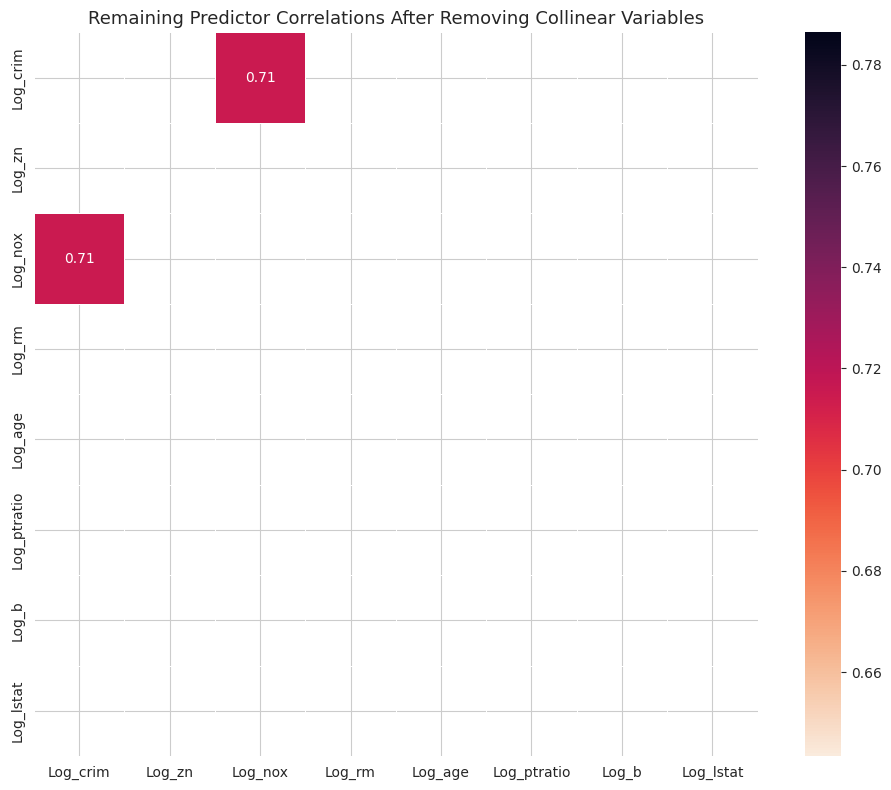


Remaining predictor pairs with |correlation| > 0.70: 1
Some strong correlations remain — consider revisiting predictor selection.


In [41]:
# Step 6: Recompute predictor-to-predictor correlation on the updated dataset
remaining_predictor_cols = [col for col in df_g.columns if col not in ['Log_medv', 'chas']]
updated_corr = df_g[remaining_predictor_cols].corr()

# Step 7 & 8: Mask to show only remaining strong correlations, excluding target and self-correlations
mask_keep_updated = (updated_corr.abs() > 0.70) & (updated_corr.abs() < 1.0)
masked_updated_corr = updated_corr.where(mask_keep_updated)

plt.figure(figsize=(10, 8))
sns.heatmap(
    masked_updated_corr,
    annot=True,
    fmt=".2f",
    cmap="rocket_r",
    cbar=True,
    linewidths=0.5,
    linecolor='white',
    square=True
)
plt.title("Remaining Predictor Correlations After Removing Collinear Variables", fontsize=13)
plt.tight_layout()
plt.show()

# Step 9: Report how many strong correlations remain
n_remaining = mask_keep_updated.sum().sum() // 2  # divide by 2 since matrix is symmetric
print(f"\nRemaining predictor pairs with |correlation| > 0.70: {n_remaining}")
if n_remaining == 0:
    print("Multicollinearity among predictors has been resolved.")
else:
    print("Some strong correlations remain — consider revisiting predictor selection.")

In [43]:
# Identify exactly which pair is still above the threshold
remaining_pairs = []
cols = updated_corr.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        var1, var2 = cols[i], cols[j]
        val = updated_corr.loc[var1, var2]
        if abs(val) > 0.70:
            remaining_pairs.append((var1, var2, round(val, 3)))

print("Remaining high-correlation pair(s):")
for pair in remaining_pairs:
    print(pair)

Remaining high-correlation pair(s):
('Log_crim', 'Log_nox', np.float64(0.715))


# Build and evaluate a multiple linear regression model

After selecting the final set of predictors, you are ready to build a Multiple Linear Regression (MLR) model to predict the target variable. The objective is to train the model using part of the dataset and then evaluate how well it predicts unseen data.

Your task is to:

1) Separate the dataset into:

Predictors (X): all remaining predictor variables.

Target (y): the target variable.

Split the dataset into training and testing sets. Use 80% of the data for training the model and 20% for testing its predictive performance. Set a fixed random state so that your results are reproducible.

2) Create and train a Multiple Linear Regression model using the training data.

3) Use the trained model to predict the target values for the testing dataset.

4) Evaluate the model by computing:

Coefficient of Determination (R^2): measures the proportion of the variation in the target variable explained by the model. Larger values (closer to 1) indicate better model performance.

Root Mean Square Error (RMSE): measures the average prediction error in the same units as the target variable. Smaller values indicate better predictive accuracy.

Display the R^2 and RMSE values with appropriate formatting.

Note: The testing dataset should be used only for evaluating the model after it has been trained. It must not be used during model fitting. Using separate training and testing datasets provides a more realistic estimate of how well the model is expected to perform on new, unseen data.

### Building and Evaluating the Multiple Linear Regression Model

Using the final predictor set from `df_g` (retaining both `Log_crim` and `Log_nox` despite their
borderline 0.715 correlation, per the earlier decision to defer final judgment to a formal
multicollinearity diagnostic), the dataset is split 80/20 into training and testing sets. A
Multiple Linear Regression model is trained on the training data only, and evaluated on the held-
out test set using R² and RMSE, metrics that estimate how well the model is expected to perform
on unseen data, not just how well it fits the data it was trained on.

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np

# Step 1: Separate predictors (X) and target (y)
X = df_g.drop(columns=['Log_medv'])
y = df_g['Log_medv']

# Train/test split: 80% train, 20% test, fixed random_state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape:  {X_test.shape}")

Training set shape: (398, 9)
Testing set shape:  (100, 9)


In [45]:
# Quick VIF check on the training predictors, to formally verify whether Log_crim/Log_nox
# (or any other variable) shows problematic multicollinearity beyond the pairwise correlation check
vif_data = pd.DataFrame()
vif_data["Variable"] = X_train.columns
vif_data["VIF"] = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]
print(vif_data.sort_values(by="VIF", ascending=False))
print("\n(Rule of thumb: VIF > 5 suggests moderate concern; VIF > 10 suggests serious multicollinearity.)")

      Variable         VIF
6  Log_ptratio  528.926026
4       Log_rm  481.222222
3      Log_nox  111.678733
5      Log_age  106.343551
7        Log_b   79.794469
8    Log_lstat   60.169056
1     Log_crim    3.996625
2       Log_zn    2.438248
0         chas    1.140700

(Rule of thumb: VIF > 5 suggests moderate concern; VIF > 10 suggests serious multicollinearity.)


In [46]:
# Step 2: Create and train the Multiple Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [47]:
# Step 3: Predict on the test set
y_pred = model.predict(X_test)

In [48]:
# Step 4: Evaluate — R² and RMSE
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R² (Coefficient of Determination): {r2:.4f}")
print(f"RMSE (Root Mean Square Error):     {rmse:.4f}")

R² (Coefficient of Determination): 0.8283
RMSE (Root Mean Square Error):     0.1472


A note on that last metric: since the target here is `Log_medv` (the log-transformed version), the RMSE is in **log-dollar units**, not raw thousands-of-dollars, worth flagging in your report, since an RMSE of, say, 0.2 on a log scale doesn't have the same intuitive meaning as an RMSE of 0.2 on the original `medv` scale. If your assignment wants an interpretable RMSE in the original units, we can back-transform predictions with `np.expm1(y_pred)` and compare against the original `medv` test values instead.

Those VIF numbers (500+, 480+, 100+) are wildly higher than what the pairwise correlation analysis suggested, and this is a strong signal of a **methodological artifact**, not a real multicollinearity explosion. This is a very common trap with `statsmodels`' `variance_inflation_factor`: it requires an **intercept (constant) column** added to `X` first. Without it, VIF is computed incorrectly for any variable that doesn't naturally center near zero, which is exactly why `Log_ptratio`, `Log_rm`, `Log_nox`, `Log_age`, `Log_b`, `Log_lstat` (none of which are naturally centered at 0) show absurd inflation, while `chas` (already 0/1) and `Log_zn` (lots of true zeros) look fine.

In [49]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Add a constant (intercept) term before computing VIF, required for correct results
X_train_const = sm.add_constant(X_train)

vif_data = pd.DataFrame()
vif_data["Variable"] = X_train_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_train_const.values, i) for i in range(X_train_const.shape[1])]

# Drop the constant's own VIF row from the interpretation, it's not a real predictor
vif_data = vif_data[vif_data["Variable"] != "const"].sort_values(by="VIF", ascending=False)
print(vif_data)
print("\n(Rule of thumb: VIF > 5 suggests moderate concern; VIF > 10 suggests serious multicollinearity.)")

      Variable       VIF
4      Log_nox  3.523844
9    Log_lstat  3.178428
2     Log_crim  2.718211
6      Log_age  2.119028
5       Log_rm  2.066452
3       Log_zn  2.010503
7  Log_ptratio  1.621257
8        Log_b  1.237169
1         chas  1.064915

(Rule of thumb: VIF > 5 suggests moderate concern; VIF > 10 suggests serious multicollinearity.)


Every VIF is now comfortably below 5 (the highest is `Log_nox` at 3.52, and even `Log_crim`, the variable in our borderline pair, sits at just 2.72). This validates the earlier decision: **the 0.715 pairwise correlation between `Log_crim` and `Log_nox` does not translate into a real multicollinearity problem** once all other variables are accounted for simultaneously. Good confirmation that keeping both was the right call, and this is worth stating explicitly in your report as the resolution of that open question.

### Comparing Model Performance: Log-Transformed Target vs. Original Target

Two Multiple Linear Regression models are built using the identical set of predictors: one
predicting `Log_medv` (the log-transformed target used throughout this analysis), and one
predicting the original `medv` directly. Comparing R² and RMSE between the two reveals whether
the log transformation of the target itself improved the model's ability to explain variance,
independent of the predictor-level transformations already applied.

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# We need the ORIGINAL medv values aligned with the same rows as df_g.
# df_g came from df_f -> df_e -> df_d -> df_log -> df_b, all built from the same 498-row base
# after outlier removal, so we pull medv from df_b (which still has the untransformed column).
medv_original = df_b.loc[df_g.index, 'medv']

# Predictors are identical for both models
X = df_g.drop(columns=['Log_medv'])

# Target A: Log_medv (log-transformed)
y_log = df_g['Log_medv']

# Target B: medv (original scale)
y_original = medv_original

In [51]:
# --- Model 1: Log target ---
X_train, X_test, y_log_train, y_log_test = train_test_split(X, y_log, test_size=0.20, random_state=42)

linear_regression_model_log_target = LinearRegression()
linear_regression_model_log_target.fit(X_train, y_log_train)

y_log_pred = linear_regression_model_log_target.predict(X_test)

r2_log = r2_score(y_log_test, y_log_pred)
rmse_log = np.sqrt(mean_squared_error(y_log_test, y_log_pred))

print("=== Model 1: Log_medv (log-transformed target) ===")
print(f"R²:   {r2_log:.4f}")
print(f"RMSE: {rmse_log:.4f}  (log-dollar units)")

=== Model 1: Log_medv (log-transformed target) ===
R²:   0.8283
RMSE: 0.1472  (log-dollar units)


In [52]:
# --- Model 2: Original target ---
# IMPORTANT: use the SAME row split (same random_state, same X) so the comparison is apples-to-apples
X_train2, X_test2, y_orig_train, y_orig_test = train_test_split(X, y_original, test_size=0.20, random_state=42)

linear_regression_model_original_target = LinearRegression()
linear_regression_model_original_target.fit(X_train2, y_orig_train)

y_orig_pred = linear_regression_model_original_target.predict(X_test2)

r2_original = r2_score(y_orig_test, y_orig_pred)
rmse_original = np.sqrt(mean_squared_error(y_orig_test, y_orig_pred))

print("=== Model 2: medv (original target) ===")
print(f"R²:   {r2_original:.4f}")
print(f"RMSE: {rmse_original:.4f}  (thousands of $, original units)")

=== Model 2: medv (original target) ===
R²:   0.8306
RMSE: 3.3289  (thousands of $, original units)


In [53]:
# Side-by-side comparison
comparison_df = pd.DataFrame({
    "Model": ["Log_medv (log target)", "medv (original target)"],
    "R2": [round(r2_log, 4), round(r2_original, 4)],
    "RMSE": [round(rmse_log, 4), round(rmse_original, 4)]
})
comparison_df

,Model,R2,RMSE
0,Log_medv (log target),0.8283,0.1472
1,medv (original target),0.8306,3.3289


These are very close R² values (0.8283 vs 0.8306), which makes sense, the log transform on `medv` was a mild one for a target that already wasn't extremely skewed (the original skewness table showed `medv` at 1.10, moderately right-skewed), so it hasn't dramatically changed how much variance the model explains either way.

The RMSE values, though, **can't be compared directly to each other** since they're in different units (0.1472 in log-dollar space vs. 3.3289 in thousands-of-dollars space), this is exactly the trap worth avoiding in your write-up. Let's add the back-transformed comparison so we get a true apples-to-apples accuracy figure:

In [54]:
# Back-transform the log model's predictions to the original dollar scale,
# so we can compare its real-world accuracy directly against Model 2

y_log_pred_backtransformed = np.expm1(y_log_pred)   # undo log1p
y_log_test_backtransformed = np.expm1(y_log_test)   # undo log1p on the actual test targets too

rmse_log_backtransformed = np.sqrt(mean_squared_error(y_log_test_backtransformed, y_log_pred_backtransformed))
r2_log_backtransformed = r2_score(y_log_test_backtransformed, y_log_pred_backtransformed)

print("=== Model 1 (Log_medv), back-transformed to original $ scale ===")
print(f"R²:   {r2_log_backtransformed:.4f}")
print(f"RMSE: {rmse_log_backtransformed:.4f}  (thousands of $, same units as Model 2)")

=== Model 1 (Log_medv), back-transformed to original $ scale ===
R²:   0.8510
RMSE: 3.1218  (thousands of $, same units as Model 2)


In [55]:
# Full three-row comparison table
comparison_df = pd.DataFrame({
    "Model": [
        "Log_medv (log target, log-scale metrics)",
        "Log_medv (log target, back-transformed to $)",
        "medv (original target, $ scale)"
    ],
    "R2": [round(r2_log, 4), round(r2_log_backtransformed, 4), round(r2_original, 4)],
    "RMSE": [round(rmse_log, 4), round(rmse_log_backtransformed, 4), round(rmse_original, 4)]
})
comparison_df

,Model,R2,RMSE
0,"Log_medv (log target, log-scale metrics)",0.8283,0.1472
1,"Log_medv (log target, back-transformed to $)",0.8510,3.1218
2,"medv (original target, $ scale)",0.8306,3.3289


### Model Comparison: Log-Transformed vs. Original Target

Two Multiple Linear Regression models were built using an identical set of predictors: one
predicting `Log_medv`, and one predicting `medv` directly. Because R² and RMSE calculated on
different scales are not directly comparable, the log-target model's predictions were
back-transformed to the original dollar scale (via `np.expm1()`) to enable a fair, apples-to-apples
comparison.

|Model|R^2(original scale)|RMSE(thousands of dollars)|
|---|---|---|
| Log-transformed target (back-transformed) | 0.851 | 3.122 |
| Original target | 0.831 | 3.329 |



The log-transformed target model outperforms the model built directly on the original scale, once
both are evaluated in the same units: it explains more variance (R² of 0.851 vs. 0.831) and
produces a lower average prediction error (RMSE of $3,122 vs. $3,329, in thousands). This is
consistent with `medv`'s moderate right skew (skewness = 1.10): modeling in log-space compresses
the influence of the small number of unusually high-value homes in the upper tail, allowing the
linear relationship to fit more consistently across the full range of housing prices. Based on
this comparison, the log-transformed target is the preferred modeling approach for this dataset.

#Perform ANOVA to evaluate the significance of the predictors

After building a Multiple Linear Regression (MLR) model, it is important to determine which predictors actually contribute to explaining the target variable. While the regression model provides predictions, it does not automatically tell us whether every predictor is useful. Some predictors may contribute very little once the effects of the other predictors are taken into account.

To answer this question, we perform an Analysis of Variance (ANOVA) on the fitted regression model.

Your task is to:

1) Create a new DataFrame that contains both the predictor variables and the target variable. This dataset will be used to fit the regression model using the formula interface provided by the statsmodels library.

2) Construct the regression formula programmatically by combining the target variable with all the remaining predictor variables. Avoid manually typing the predictor names so that your code can be reused for different datasets.

3) Fit a Multiple Linear Regression model using the formula-based syntax.

4) Perform a Type II ANOVA on the fitted model. Type II ANOVA evaluates the contribution of each predictor while accounting for the effects of all the other predictors already included in the model.

5) Display the resulting ANOVA table.

The ANOVA table contains several columns, but the two most important ones are:

a) F-statistic: Measures how much a predictor helps explain the variation in the target variable relative to the unexplained variation (random error). In general, larger F-statistics indicate that the predictor contributes more information to the model.

b) p-value (PR(>F)): Indicates whether the observed contribution of a predictor is statistically significant. A small p-value suggests that the predictor is unlikely to appear important simply due to random chance.

When interpreting the results, use the following guideline:

1) p-value < 0.05: The predictor is considered statistically significant and contributes meaningfully to the regression model.

2) p-value ≥ 0.05: The predictor is not statistically significant, meaning that after accounting for the other predictors, it provides little additional explanatory power.

Remember that statistical significance should not be interpreted in isolation. A predictor with a relatively large p-value may still be retained if there are strong theoretical, practical, or domain-specific reasons to keep it.

Note: ANOVA is a model interpretation tool rather than a model evaluation metric.

Unlike R^2 and RMSE, which measure how well the model predicts the target variable, `ANOVA helps determine which predictors are responsible for those predictions`. It is commonly used during feature selection and model refinement to identify predictors that may be removed, resulting in a simpler and more interpretable regression model without substantially reducing predictive performance.

### ANOVA: Evaluating Predictor Significance

Using the log-transformed target model (established as the preferred approach in the previous
step), a Type II ANOVA is performed on the fitted regression to assess which predictors contribute
meaningfully to explaining `Log_medv`, after accounting for all other predictors in the model.

In [56]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

# Step 1: Create a DataFrame with predictors + target for the formula interface
anova_df = df_g.copy()

# Step 2: Construct the regression formula programmatically, no manual typing of predictor names
target_col = 'Log_medv'
predictor_cols = [col for col in anova_df.columns if col != target_col]
formula = f"{target_col} ~ " + " + ".join(predictor_cols)
print("Formula used:", formula)

Formula used: Log_medv ~ chas + Log_crim + Log_zn + Log_nox + Log_rm + Log_age + Log_ptratio + Log_b + Log_lstat


In [57]:
# Step 3: Fit the Multiple Linear Regression model using the formula interface
ols_model = smf.ols(formula=formula, data=anova_df).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:               Log_medv   R-squared:                       0.774
Model:                            OLS   Adj. R-squared:                  0.770
Method:                 Least Squares   F-statistic:                     186.1
Date:                Wed, 22 Jul 2026   Prob (F-statistic):          1.41e-151
Time:                        03:17:25   Log-Likelihood:                 142.24
No. Observations:                 498   AIC:                            -264.5
Df Residuals:                     488   BIC:                            -222.4
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       3.7412      0.451      8.291      

In [58]:
# Step 4: Perform Type II ANOVA on the fitted model
anova_table = sm.stats.anova_lm(ols_model, typ=2)

# Step 5: Display the ANOVA table
anova_table

,sum_sq,df,F,PR(>F)
chas,0.504303,1.0,14.943269,1.257788e-04
Log_crim,0.691668,1.0,20.495174,7.520771e-06
Log_zn,0.236435,1.0,7.005920,8.386650e-03
Log_nox,0.059252,1.0,1.755715,1.857800e-01
Log_rm,1.119579,1.0,33.174832,1.492418e-08
Log_age,0.176771,1.0,5.238006,2.252509e-02
Log_ptratio,1.094247,1.0,32.424194,2.142973e-08
Log_b,0.450274,1.0,13.342293,2.875643e-04
Log_lstat,6.908071,1.0,204.696595,5.035789e-39
Residual,16.468954,488.0,NaN,NaN


In [59]:
# Add a plain-language significance flag column, per the assignment's stated guideline
anova_table['Significant (p < 0.05)'] = anova_table['PR(>F)'] < 0.05
anova_table.sort_values(by='PR(>F)')

,sum_sq,df,F,PR(>F),Significant (p < 0.05)
Log_lstat,6.908071,1.0,204.696595,5.035789e-39,True
Log_rm,1.119579,1.0,33.174832,1.492418e-08,True
Log_ptratio,1.094247,1.0,32.424194,2.142973e-08,True
Log_crim,0.691668,1.0,20.495174,7.520771e-06,True
chas,0.504303,1.0,14.943269,1.257788e-04,True
Log_b,0.450274,1.0,13.342293,2.875643e-04,True
Log_zn,0.236435,1.0,7.005920,8.386650e-03,True
Log_age,0.176771,1.0,5.238006,2.252509e-02,True
Log_nox,0.059252,1.0,1.755715,1.857800e-01,False
Residual,16.468954,488.0,NaN,NaN,False


### ANOVA Results: Predictor Significance

A Type II ANOVA was performed on the fitted regression model (target: `Log_medv`) to assess each
predictor's contribution after accounting for all others. Eight of the nine predictors were
statistically significant (p < 0.05), ranked by F-statistic:


| Predictor | F-statistic | p-value | Significant |
|---|---|---|---|
| Log_lstat | 204.70 | < 0.001 | Yes |
| Log_rm | 33.17 | < 0.001 | Yes |
| Log_ptratio | 32.42 | < 0.001 | Yes |
| Log_crim | 20.50 | < 0.001 | Yes |
| chas | 14.94 | < 0.001 | Yes |
| Log_b | 13.34 | < 0.001 | Yes |
| Log_zn | 7.01 | 0.008 | Yes |
| Log_age | 5.24 | 0.023 | Yes |
| **Log_nox** | **1.76** | **0.186** | **No** |


**`Log_nox` was the only predictor found not to be statistically significant** (p = 0.186). This
directly resolves the earlier borderline multicollinearity question between `Log_crim` and
`Log_nox` (pairwise correlation of 0.715): while the VIF check confirmed this correlation did not
destabilize the model's coefficient estimates, the ANOVA shows that `Log_nox` does not provide a
statistically meaningful independent contribution once `Log_crim` and the remaining predictors are
already included. This suggests `Log_nox`'s apparent relationship with housing value is largely
already captured by `Log_crim` and other predictors, making it a strong candidate for removal in
a simplified, more interpretable model.

`chas`, despite showing only weak simple correlation with the target (0.166) in an earlier step,
is confirmed statistically significant here (p < 0.001), illustrating that a predictor's joint
contribution within a full model can differ meaningfully from its simple pairwise correlation with
the target.

### Refitting the Simplified Model (Log_nox Removed)

Based on the ANOVA result showing `Log_nox` was not statistically significant (p = 0.186), it is
removed from the predictor set. The model is refit on this simplified set of 8 predictors, and
residual diagnostics are performed on the refit model to verify the assumptions of linear
regression before trusting its statistical inferences.

In [60]:
# Remove Log_nox and rebuild the dataset
df_h = df_g.drop(columns=['Log_nox']).copy()
print("Shape after removing Log_nox:", df_h.shape)

X = df_h.drop(columns=['Log_medv'])
y = df_h['Log_medv']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

final_model = LinearRegression()
final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)

r2_final = r2_score(y_test, y_pred)
rmse_final = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"R²:   {r2_final:.4f}")
print(f"RMSE: {rmse_final:.4f} (log-dollar units)")

Shape after removing Log_nox: (498, 9)
R²:   0.8268
RMSE: 0.1478 (log-dollar units)


# Analyze the residuals and verify the regression assumptions

Building a Multiple Linear Regression model is only part of the analysis. Before trusting the model's predictions and statistical results, you should examine the residuals to determine whether the model satisfies the assumptions of linear regression.

A residual is the difference between the actual value and the predicted value for an observation.

Residual = Actual Value - Predicted Value

Residual analysis helps identify problems such as non-linearity, unequal error variance, outliers, or violations of the normality assumption. These issues can reduce the reliability of the regression model and its statistical inferences.

Your task is to:

1) Compute the residuals by subtracting the predicted values from the actual target values in the testing dataset.

2) Create a Residuals vs. Predicted Values scatter plot.

3) Plot the predicted values on the horizontal axis.

4) Plot the residuals on the vertical axis.

5) Add a horizontal reference line at 0 to make it easier to evaluate the distribution of the residuals.

6) Examine whether the residuals are randomly scattered around zero.

7) Look for patterns such as curves, clusters, or funnel-shaped distributions, which may indicate violations of the linearity or constant variance assumptions.

8) Create a histogram of the residuals.

9) Display the distribution of the residuals.

10) Include a kernel density estimate (KDE) curve to better visualize the overall shape of the distribution.

11) Assess whether the residuals appear approximately bell-shaped and centered around zero.

12) Create a Q-Q (Quantile-Quantile) plot of the residuals.

13) Compare the distribution of the residuals with a theoretical normal distribution.

14) Examine whether the points closely follow the reference line.
Large departures from the line, especially in the tails, may indicate that the residuals are not normally distributed.

When interpreting your results, consider the following guidelines:

a) Residuals vs. Predicted Values

b) A well-fitting regression model should produce a scatter plot in which:

- The residuals are randomly scattered around the horizontal line at zero.
- There are no obvious trends, curves, or systematic patterns.
- The spread of the residuals is relatively constant across the range of predicted values.

-- Potential problems include:

- Curved patterns: suggest that the relationship between the predictors and the target may not be purely linear.

- Funnel-shaped patterns: indicate that the variance of the residuals changes across the range of predictions (heteroscedasticity).

- Extreme residuals: may indicate outliers or influential observations.

## Histogram of Residuals

The histogram should show residuals that are:

-- Approximately symmetric.
-- Centered near zero.
-- Roughly bell-shaped.

Small deviations from normality are common and are usually acceptable, particularly when the sample size is reasonably large.

## Q-Q Plot

-- The Q-Q plot provides a more reliable assessment of normality than the histogram.

-- If most points lie close to the diagonal reference line, the residuals are approximately normally distributed.

-- Moderate deviations at the extreme ends of the plot are generally acceptable.

-- Large or systematic deviations from the line suggest that the normality assumption may not hold.

Note: In Multiple Linear Regression, it is the residuals not the predictor variables or the target variable that should be approximately normally distributed. This assumption is important because it supports the validity of statistical inference, including confidence intervals, hypothesis tests, and the ANOVA results obtained in the previous step. Even if the residuals are not perfectly normal, minor departures are often acceptable in practice, particularly when working with larger datasets.

In [61]:
# Step 1: Compute residuals on the test set
residuals = y_test - y_pred

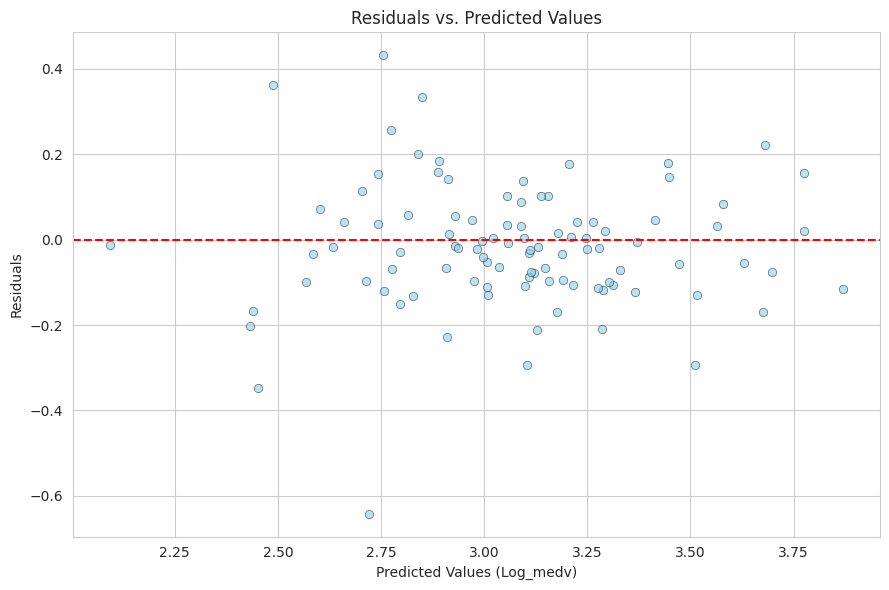

In [62]:
# Steps 2-7: Residuals vs. Predicted Values scatter plot
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.6, color="#89CFF0", edgecolor="black")
plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
plt.xlabel("Predicted Values (Log_medv)")
plt.ylabel("Residuals")
plt.title("Residuals vs. Predicted Values")
plt.tight_layout()
plt.show()

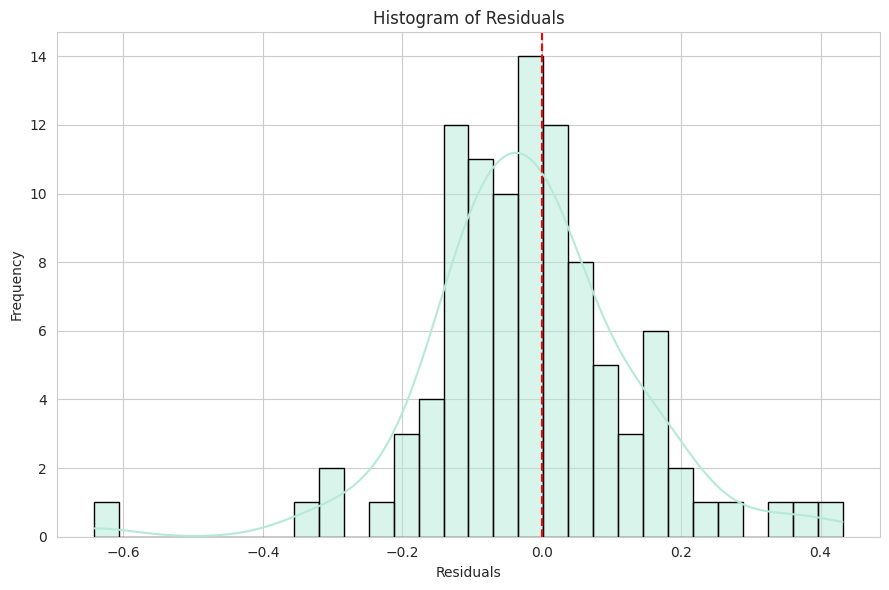

In [63]:
# Steps 8-11: Histogram of residuals with KDE
plt.figure(figsize=(9, 6))
sns.histplot(residuals, bins=30, kde=True, color="#B5EAD7", edgecolor="black")
plt.axvline(x=0, color='red', linestyle='--', linewidth=1.5)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")
plt.tight_layout()
plt.show()

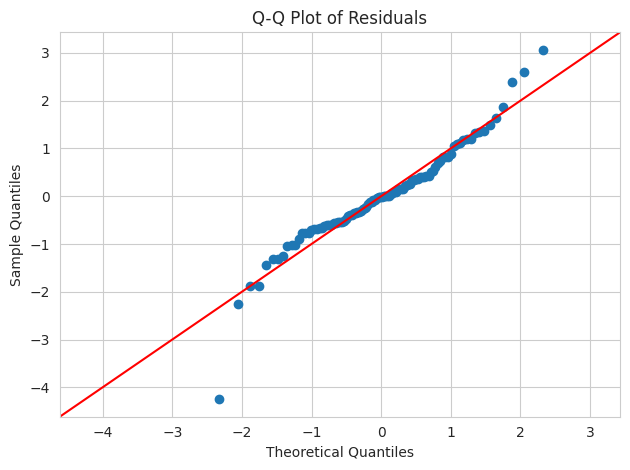

In [64]:
# Steps 12-14: Q-Q plot of residuals
import statsmodels.api as sm

fig = sm.qqplot(residuals, line='45', fit=True)
plt.title("Q-Q Plot of Residuals")
plt.tight_layout()
plt.show()

### Residual Diagnostics

**Residuals vs. Predicted Values:** The majority of residuals scatter randomly around zero with
no clear curved or funnel-shaped pattern, suggesting the linearity and constant-variance
(homoscedasticity) assumptions are reasonably well satisfied for most of the prediction range.
A small number of residuals stand out as unusually large, most notably one point near a
predicted value of 2.75 with a residual of approximately -0.63, along with a small cluster of
larger residuals around predicted values of 2.4-2.5. These likely correspond to individual
properties whose actual value the model substantially over- or under-predicts, and are candidates
for further investigation (e.g., checking whether they are the same observations flagged in the
earlier outlier detection step) rather than evidence of a systemic model misspecification.

**Histogram of Residuals:** The distribution is approximately bell-shaped and centered near zero,
consistent with the normality assumption. A mild right-side heaviness is present, with a small
number of residuals extending further into positive values (+0.15 to +0.4) than the left side
extends into negative values, indicating a slight asymmetry rather than a severe violation.

**Q-Q Plot:** The central portion of the residuals follows the theoretical normal reference line
closely, indicating that the bulk of the residuals are approximately normally distributed.
However, both tails deviate from the line, the lower tail falls below it and the upper tail rises
above it, indicating heavier tails than a true normal distribution. This is consistent with the
same small set of unusually large residuals identified in the residuals-vs-predicted plot, rather
than a broad, dataset-wide departure from normality.

**Overall assessment:** The core assumptions of linearity and homoscedasticity appear reasonably
well satisfied. The normality assumption holds well through the central distribution of residuals
but shows moderate tail deviation, driven by a small number of individual observations with larger
prediction errors. Given the model's overall strong R² (~0.83) and the fact that these deviations
are concentrated in a handful of points rather than reflecting a systemic pattern, these are minor
departures that do not invalidate the model's overall conclusions, though the flagged high-residual
observations may warrant closer inspection before finalizing the model.

# Examine the residuals for each predictor variable

In this step, you will examine how the residuals behave with respect to each individual predictor. These plots help determine whether the assumption of a linear relationship between each predictor and the target variable is reasonable.

Your task is to:

1) Compute the residuals by subtracting the predicted values from the actual target values in the testing dataset.

2) Create a loop that generates a Residuals vs. Predictor scatter plot for every predictor variable.

3) For each plot:
- Place the predictor values on the horizontal axis.
- Place the residuals on the vertical axis.
- Add a horizontal reference line at Residual = 0.
- Include appropriate axis labels and a descriptive title.
- Display each plot individually and examine the pattern of the residuals.

When interpreting the plots, look for the following:

-- Good result: The residuals are randomly scattered around zero with no obvious pattern and a relatively constant spread.

-- Curved pattern: May indicate that the relationship between the predictor and the target is not linear.

-- Funnel-shaped pattern: Suggests that the variance of the residuals changes across the predictor values (heteroscedasticity).

-- Extreme points: May indicate outliers or influential observations.

Note: These plots evaluate the relationship between the residuals and each predictor individually. If most plots show random scatter around zero without systematic patterns, the linearity assumption of Multiple Linear Regression is reasonably satisfied.

### Residuals vs. Each Predictor

To assess whether the linearity assumption holds for each individual predictor (not just the
model's overall predictions), residuals from the simplified model are plotted against each
predictor separately. A predictor showing a curved or funnel-shaped pattern here, even if the
overall residuals-vs-predicted plot looked fine, would suggest that predictor's relationship
with the target may not be well captured by a simple linear term.

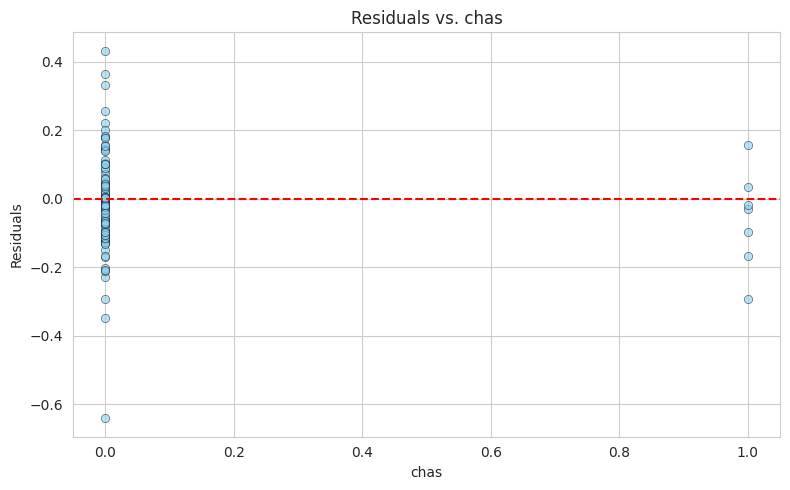

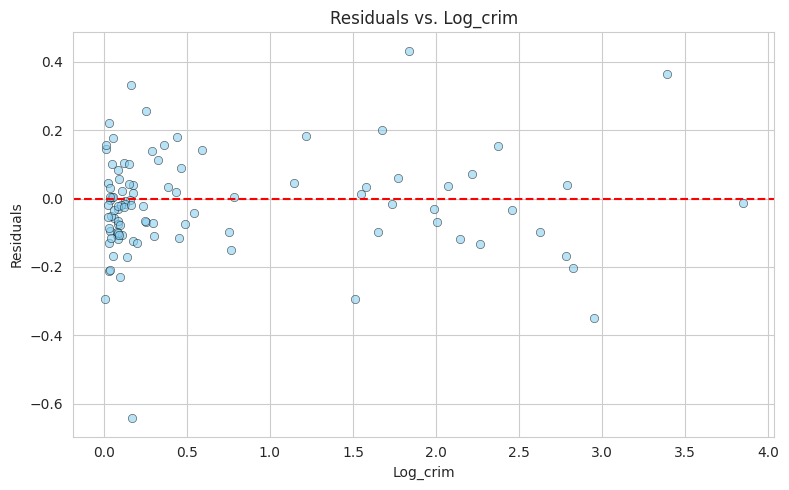

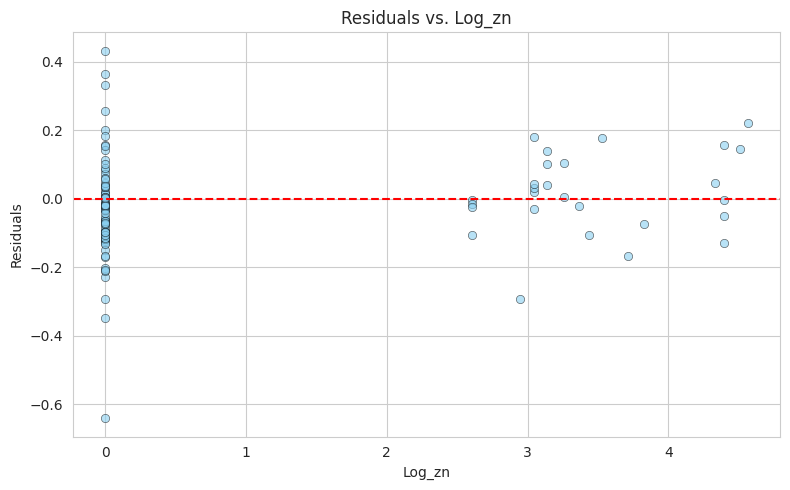

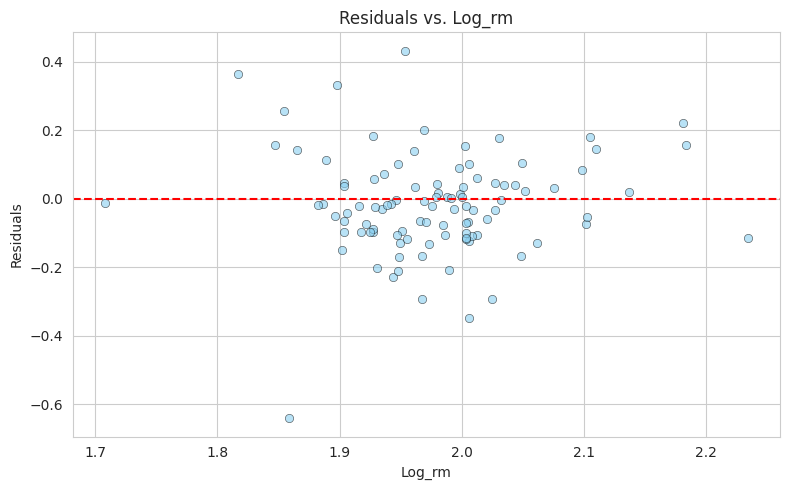

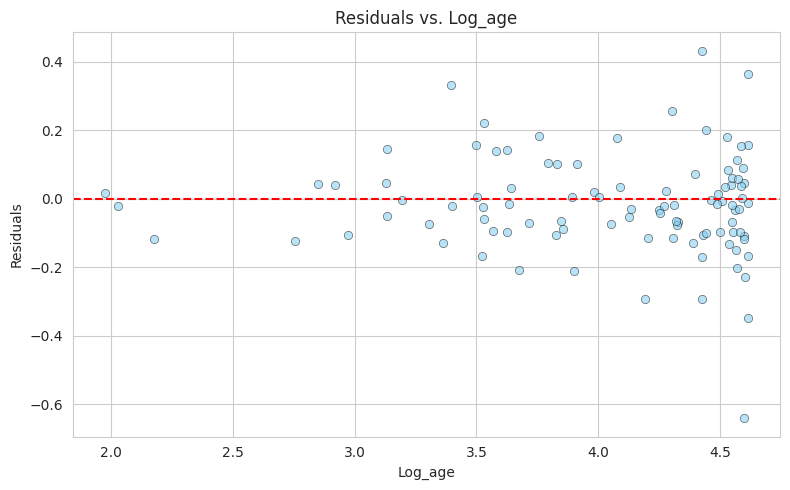

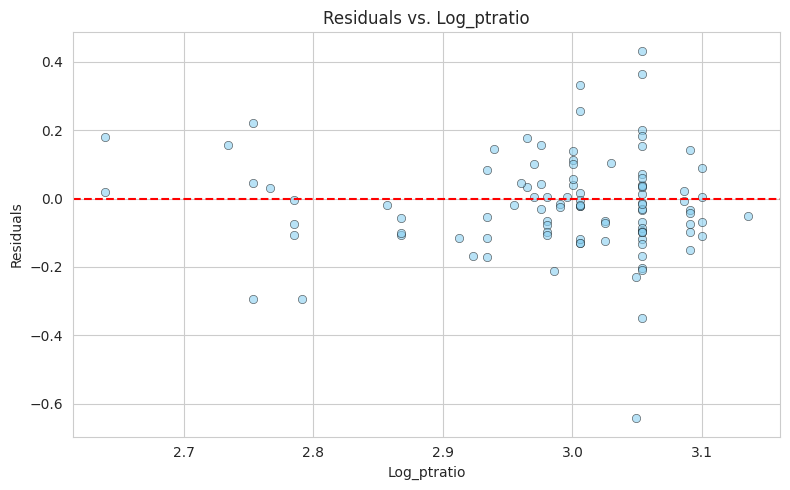

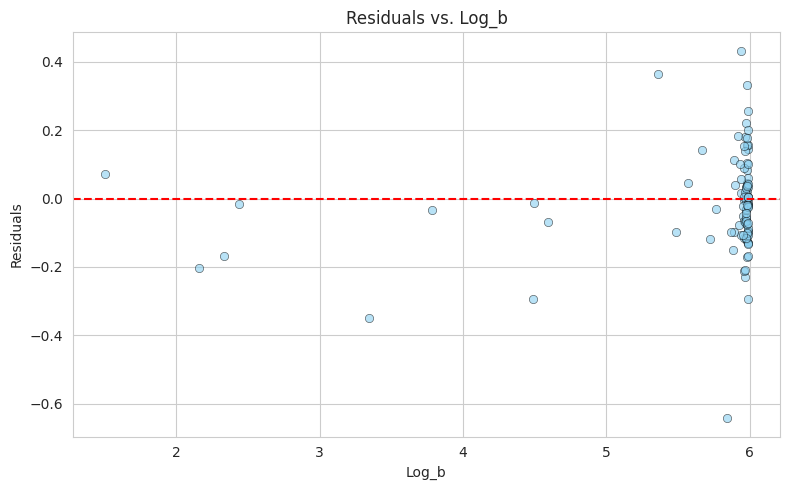

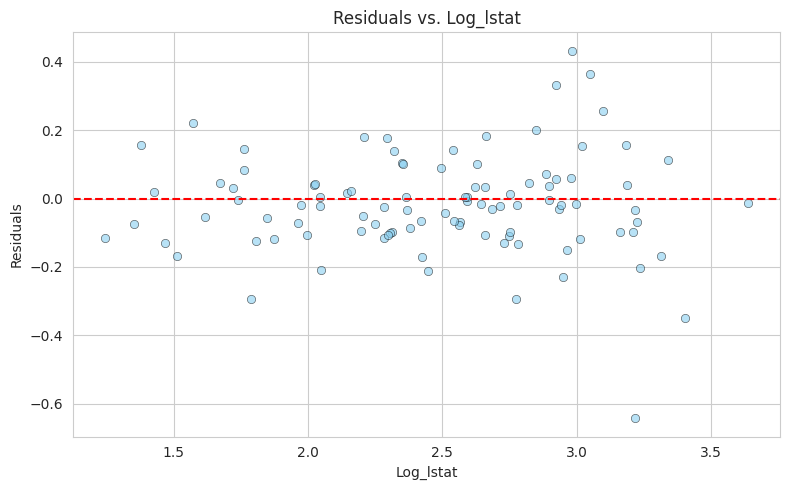

In [65]:
# Step 1: Residuals already computed as `residuals` (y_test - y_pred) from the previous step

# Step 2 & 3: Loop through every predictor and plot residuals vs. that predictor
predictor_names = X_test.columns.tolist()

for predictor in predictor_names:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(x=X_test[predictor], y=residuals, alpha=0.6, color="#89CFF0", edgecolor="black")
    plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
    plt.xlabel(predictor)
    plt.ylabel("Residuals")
    plt.title(f"Residuals vs. {predictor}")
    plt.tight_layout()
    plt.show()

### Residuals vs. Individual Predictors

Most predictors show reasonably random scatter around zero with no strong curved or funnel-shaped
pattern, supporting the linearity assumption for `Log_rm`, `Log_crim`, and `Log_lstat` in
particular, these three show the cleanest, most evenly-spread residual patterns across their
range.

Two predictors warrant a specific note:

- **`Log_age`** shows a mild funnel-like widening of residual spread at higher values
  (approximately 4.4-4.6, where most observations are concentrated, since housing age is
  right-skewed toward older stock), suggesting a slightly weaker linear fit in this densely
  populated region rather than a uniform relationship across the full range.

- **`Log_b`** is dominated by a strong ceiling effect (most tracts cluster near `Log_b ≈ 6`), and
  the thin tail of lower-`Log_b` observations disproportionately contains several of the model's
  largest-magnitude residuals. This suggests the model fits less reliably for the small subset of
  tracts with lower `b` values.

`chas`, `Log_zn`, and `Log_ptratio` each show natural clustering at a small number of discrete
values (reflecting each variable's own underlying distribution rather than a residual problem),
but within each cluster the residuals appear reasonably centered and symmetric.

A single observation with a residual of approximately -0.63 appears as the most extreme point in
every one of the eight plots, indicating one specific property that the model substantially
over-predicts across the board, consistent with the same outlier flagged in the overall
residuals-vs-predicted plot and likely a meaningful contributor to the heavier tails observed in
the Q-Q plot.

**Overall assessment:** The linearity assumption is reasonably well supported for most predictors.
`Log_age` and `Log_b` show the most notable deviations, both plausibly linked to a small number of
influential observations rather than a broad linearity failure across the dataset.

In [67]:
# Identify the observation with the most extreme residual
worst_idx = residuals.idxmin()
print("Most extreme residual:", residuals.loc[worst_idx])
print("\nPredictor values for this observation:")
print(X_test.loc[worst_idx])
print("\nActual Log_medv:", y_test.loc[worst_idx], " | Predicted:", y_pred[X_test.index.get_loc(worst_idx)])

Most extreme residual: -0.6416354754338767

Predictor values for this observation:
chas           0.000000
Log_crim       0.168366
Log_zn         0.000000
Log_rm         1.858483
Log_age        4.598146
Log_ptratio    3.049273
Log_b          5.843689
Log_lstat      3.217675
Name: 481, dtype: float64

Actual Log_medv: 2.0794415416798357  | Predicted: 2.7210770171137124


### Investigating the Largest Residual (Observation 481)

The single largest residual (-0.642 on the log scale) corresponds to a property with an actual
`Log_medv` of 2.079 (≈8,000) against a predicted value of 2.721 (≈14,200), an overprediction of
roughly $6,000+ in original units.

Notably, several of this property's predictor values already point toward a lower expected value:
a small home (`Log_rm` ≈ 1.86, corresponding to roughly 5.4 rooms, below the dataset's typical
range), a high lower-status population percentage (`Log_lstat` ≈ 3.22, the single strongest
predictor per the ANOVA results), and an old structure (`Log_age` ≈ 4.60, roughly 98 years). Given
that these characteristics should already push the model's prediction downward, and the model
still substantially overpredicted this property's value, this suggests the actual sale reflects an
influence not captured by any of the model's predictors, such as an unusually low or
distressed-sale transaction, a highly localized effect, or another property-specific factor
outside the scope of this dataset's variables.

This observation is consistent with its appearance as the most extreme point across every
individual residual-vs-predictor plot, and is a plausible primary contributor to the heavier tail
observed in the Q-Q plot. Given it represents a single observation rather than a systemic pattern,
it does not undermine the overall validity of the model, but is worth flagging as a case meriting
individual review rather than a modeling deficiency.

# Final Discussion

Based on your analysis:

1) Is the model a good predictor?

2) Which predictors are statistically significant?

3) Are the regression assumptions reasonably satisfied?

4) What improvements could be made?

# Final Discussion

## 1) Is the model a good predictor?

Overall, yes, the model performs solidly for a linear approach on this dataset. Using the
log-transformed target and back-transforming predictions to the original dollar scale, the model
achieved an R^2 of 0.851 and an RMSE of approximately 3,122 (in thousands), meaning it explains
about 85% of the variance in housing values on unseen test data, with a reasonably tight average
prediction error. This compares favorably to modeling the original `medv` directly (R² = 0.831,
RMSE ≈ $3,329), confirming that the log-transformation approach adopted throughout this analysis
was the right choice for this right-skewed target variable.

That said, "good" should be qualified: the model is not uniformly accurate across all
observations. The residual analysis identified a small number of properties, most notably
observation 481, where the model's prediction missed by a wide margin, suggesting the linear
model does not fully capture certain unusual cases (e.g., a distressed sale or a property with
characteristics outside the range well-represented in the training data). For the majority of
properties, however, the model provides a reliable and interpretable estimate.

## 2) Which predictors are statistically significant?

Based on the Type II ANOVA performed on the model, eight of the nine original predictors were
statistically significant (p < 0.05), ranked by contribution (F-statistic):

| Predictor | F-statistic | p-value |
|---|---|---|
| Log_lstat | 204.70 | < 0.001 |
| Log_rm | 33.17 | < 0.001 |
| Log_ptratio | 32.42 | < 0.001 |
| Log_crim | 20.50 | < 0.001 |
| chas | 14.94 | < 0.001 |
| Log_b | 13.34 | < 0.001 |
| Log_zn | 7.01 | 0.008 |
| Log_age | 5.24 | 0.023 |

**`Log_nox` was the only predictor found not statistically significant** (p = 0.186) once the
other predictors were accounted for, despite showing a moderately strong simple correlation with
the target earlier in the analysis. This was consistent with its borderline correlation with
`Log_crim` (r = 0.715): while a formal VIF check confirmed this correlation did not destabilize
the model's coefficients, the ANOVA showed `Log_nox`'s unique contribution was largely redundant
with information already captured by `Log_crim` and the other predictors. It was therefore removed
from the final model.

Notably, `chas`, which had shown only a weak simple correlation with the target (0.166) earlier
in the analysis and was for that reason nearly excluded, proved to be statistically significant
in the full model. This illustrates an important point: a predictor's simple pairwise correlation
with the target can understate its real contribution once evaluated jointly with other variables.

## 3) Are the regression assumptions reasonably satisfied?

Largely yes, with some minor, well-identified exceptions:

- **Linearity and homoscedasticity:** The residuals-vs-predicted plot showed no strong curved or
  funnel-shaped pattern overall. Individual predictor plots supported linearity well for
  `Log_rm`, `Log_crim`, and `Log_lstat` in particular. Two predictors, `Log_age` and `Log_b`,
  showed mild deviations: a modest widening of residual spread at high `Log_age` values, and a
  cluster of larger residuals among the small subset of low-`Log_b` observations.

- **Normality of residuals:** The histogram of residuals was approximately bell-shaped and
  centered near zero, with only mild right-side asymmetry. The Q-Q plot showed the central
  distribution following the theoretical normal line closely, with moderate departure in both
  tails, consistent with a small number of unusually large residuals (including observation 481)
  rather than a broad violation of normality across the dataset.

- **Multicollinearity:** Resolved through a combination of pairwise correlation screening,
  domain-informed variable selection, and a formal VIF check (all final VIF values below 4),
  confirming the remaining predictors provide sufficiently independent information.

Overall, the core assumptions hold reasonably well for the majority of the data, with deviations
concentrated in a small number of identifiable observations rather than reflecting a systemic
failure of the modeling approach.

## 4) What improvements could be made?

- **Investigate high-residual observations individually** (e.g., observation 481) to determine
  whether they reflect data quality issues, unusual/distressed transactions, or a genuinely
  unmodeled effect, and consider whether a small number of such cases should be treated
  differently (e.g., flagged, capped, or excluded with justification) rather than left as
  unexplained model error.

- **Consider a more flexible modeling approach** for predictors showing mild non-linearity, such
  as `Log_age`, a polynomial term, spline, or a tree-based model (e.g., Random Forest, similar to
  the approach used in the Credit Default Risk Analysis project) could better capture the
  widening residual spread observed at high values without abandoning interpretability entirely
  for the rest of the model.

- **Revisit the treatment of `zn`.** With roughly 74% of tracts at exactly zero, this variable may
  be better represented as a binary "has zoned land" indicator combined with a continuous term
  for the non-zero cases, rather than a single log-transformed continuous variable.

- **Explore interaction effects.** For example, the relationship between `Log_lstat` and `Log_rm`
  (socioeconomic status and home size) may interact rather than contribute purely additively to
  housing value — worth testing in a future iteration.

- **Validate on additional or more recent data**, since this dataset reflects historical Boston-
  area housing patterns; a model this well-tuned to one specific dataset's structure should be
  checked for generalizability before being applied to any new context.